# EDIS 8100 · Week 8 · Mini Project 4: Networks and Temporal Learning Analytics

**Estimated time:** about 20 minutes to launch in class, roughly 90 minutes total
**Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Every dataset you have touched so far has been a table: one row per student, or one row per event, with a
number in each cell. This week we drop that assumption twice.

First we ask **who is talking to whom**, which turns the forum into a network instead of a table of posts.
Then we ask **when things happened**, which turns eight weeks of clicks and submissions into a shape rather
than a total. Both moves recover information that a summary column throws away.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Build a reply network from forum data with `networkx` and justify the modeling choices you made along the
   way (what counts as a tie, whether direction matters, who is even in the graph).
2. Compute and contrast **degree** and **betweenness** centrality, and explain in plain language why a student
   can matter enormously to a community without being one of its loudest members.
3. Detect communities with greedy modularity optimization, read a sociogram, and name what the picture hides.
4. Analyze submission timing and rolling engagement over eight weeks, and state precisely what a temporal
   pattern does and does not license you to claim.

## How this notebook works (read this if you are new to code)

- Run the cells **from top to bottom**. Click a cell and press **Shift + Enter**, or use the play button on
  the left of the cell.
- **Nothing here can break your computer.** This notebook runs on a Google server, it downloads nothing, and it
  contacts no outside service. The worst case is an error message.
- **If something looks broken, start over.** In Colab: `Runtime` > `Restart session and run all`. That fixes
  the great majority of problems, including yours.
- Cells marked **✏️ Your turn** are the ones you edit. Every one of them already contains a working value, so
  the notebook runs correctly even if you change nothing. Change things anyway. You cannot lose anything.
- An error message is not a verdict on you. Read the last line first, it usually names the problem.

## ⚙️ Setup: run the next cell first

The cell below builds this week's four datasets (`students.csv`, `forum_posts.csv`, `gradebook.csv`, and
`lms_clickstream.csv`) inside this session, so the notebook works with no downloads and no logins.

These data are **synthetic on purpose**. Nobody in this notebook is a real student, which is exactly what lets
us practice reading "student data" without surveilling anyone. The ask in return is that you treat it as if it
were real: ask who could be harmed by a claim before you make it.

In [1]:
# ============================================================================
# SETUP CELL: this is long on purpose. It is the seeded data generator, placed
# here so the notebook runs anywhere with no downloads. You do NOT need to read
# it. Collapse it (click the arrow to the left of this line) and move on.
# ============================================================================

"""EDIS 8100 data generation, the subset needed for week08.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_CLICKSTREAM = SEED + 1
SEED_GRADEBOOK = SEED + 2
SEED_FORUM = SEED + 3
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
WEEK_TOPICS = {
    1: "memory",
    2: "spacing",
    3: "metacognition",
    4: "motivation",
    5: "collaboration",
    6: "note-taking",
    7: "sleep",
    8: "test anxiety",
}
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
EVENT_TYPES = [
    "login", "page_view", "video_play", "video_pause",
    "forum_view", "assignment_view", "submit",
]
EVENT_BASE_P = np.array([0.12, 0.32, 0.16, 0.11, 0.13, 0.11, 0.05])
def make_clickstream(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """LMS event log for the eight course weeks.

    Two things vary across students and they are not the same thing. Volume is how
    many events a student generates, and it is heavy tailed. Regularity is how many
    separate days they show up at all. The week also has a rhythm: Monday and
    Tuesday spike ahead of the Tuesday night quiz deadline.

    Two subgroups break the "more clicks means more learning" story. Efficient
    students generate few events and score well (P1). First generation students
    working 15+ hours can only touch the course on a handful of days, so their
    regularity looks terrible even though their learning does not (P2).
    """
    rng = np.random.default_rng(SEED_CLICKSTREAM)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    regularity_z = _z(students["regularity"].to_numpy())
    efficient = students["efficient"].to_numpy()
    burst = students["burst_worker"].to_numpy()

    # Expected event count per student, lognormal so the tail is heavy.
    log_mu = (
        5.78
        + 0.40 * engagement
        + 0.05 * ability
        + 0.10 * regularity_z
        + np.log(np.where(efficient == 1, 0.30, 1.0))
        + np.log(np.where(burst == 1, 0.95, 1.0))
    )
    n_events = np.clip(
        np.round(np.exp(log_mu + rng.normal(0, 0.18, n))), 25, 4000
    ).astype(int)

    n_days = N_WEEKS * 7
    day_index = np.arange(n_days)
    weekday = (day_index + 0) % 7  # 0 = Monday, because 2026-09-07 is a Monday
    weekday_weight = np.array([1.45, 1.60, 1.10, 1.00, 0.75, 0.60, 1.05])
    weekday_rel = weekday_weight / weekday_weight.mean()
    week_of = day_index // 7
    week_weight = 1.0 - 0.022 * week_of  # attention fades a little across the term
    base_day_w = weekday_weight[weekday] * week_weight

    # Probability that a given student touches the course on a given day.
    p_active = _sigmoid(0.45 + 0.95 * regularity_z)
    # Working 15+ hours compresses the week into a couple of long evenings.
    p_active = np.where(burst == 1, p_active * 0.18, p_active)

    # Submit events crowd into the 48 hours before each Tuesday deadline.
    submit_day_w = np.where(np.isin(weekday, [0, 1]), 5.0, 0.70) * week_weight

    rows_student, rows_day, rows_type = [], [], []
    rows_hour = []

    for i in range(n):
        k = int(n_events[i])
        day_p = np.clip(p_active[i] * weekday_rel[weekday] * week_weight, 0.01, 0.97)
        active = rng.random(n_days) < day_p
        if active.sum() < 4:
            active[rng.choice(n_days, size=4, replace=False)] = True

        w = base_day_w * active * (0.55 + rng.gamma(3.0, 1.0 / 3.0, n_days))
        w = w / w.sum()
        sw = submit_day_w * active
        sw = sw / sw.sum()

        # Per-student taste for videos versus pages versus the forum.
        p_types = rng.dirichlet(EVENT_BASE_P * 55.0)
        types = rng.choice(len(EVENT_TYPES), size=k, p=p_types)

        days = rng.choice(n_days, size=k, p=w)
        is_submit = types == EVENT_TYPES.index("submit")
        if is_submit.any():
            days[is_submit] = rng.choice(n_days, size=int(is_submit.sum()), p=sw)

        # Time of day: three loose study sessions, later for procrastinators.
        centers = rng.choice(
            [9.6, 14.2, 20.8], size=k, p=[0.27, 0.33, 0.40]
        ) + 1.05 * procrast[i] * rng.random(k)
        hours = centers + rng.normal(0, 0.85, k)
        hours = np.clip(hours, 0.02, 23.97)

        rows_student.append(np.full(k, i))
        rows_day.append(days)
        rows_type.append(types)
        rows_hour.append(hours)

    student_idx = np.concatenate(rows_student)
    days = np.concatenate(rows_day)
    types = np.concatenate(rows_type)
    hours = np.concatenate(rows_hour)

    seconds = days * DAY_S + hours * 3600.0
    order = np.argsort(seconds, kind="stable")
    student_idx, days, types, seconds = (
        student_idx[order], days[order], types[order], seconds[order]
    )

    week = (days // 7 + 1).astype(int)
    type_names = np.array(EVENT_TYPES)[types]

    # Plausible resource ids per event type.
    resource = np.empty(seconds.size, dtype=object)
    page_no = rng.integers(1, 9, seconds.size)
    video_no = rng.integers(1, 5, seconds.size)
    thread_no = rng.integers(1, 61, seconds.size)
    for t, name in enumerate(EVENT_TYPES):
        mask = types == t
        if not mask.any():
            continue
        if name == "login":
            resource[mask] = "lms_home"
        elif name == "page_view":
            resource[mask] = [
                f"w{w}_page_{p:02d}" for w, p in zip(week[mask], page_no[mask])
            ]
        elif name in ("video_play", "video_pause"):
            resource[mask] = [
                f"w{w}_video_{v:02d}" for w, v in zip(week[mask], video_no[mask])
            ]
        elif name == "forum_view":
            resource[mask] = [f"thread_{t3:03d}" for t3 in thread_no[mask]]
        else:  # assignment_view and submit both point at the next quiz due
            deadline_days = np.array([QUIZ_DEADLINE_DAY[k] for k in range(1, N_WEEKS + 1)])
            next_quiz = np.clip(
                1 + np.searchsorted(deadline_days, days[mask], side="left"), 1, N_WEEKS
            )
            resource[mask] = [f"quiz_{k}" for k in next_quiz]

    df = pd.DataFrame(
        {
            "event_id": [f"E{i + 1:06d}" for i in range(seconds.size)],
            "student_id": students["student_id"].to_numpy()[student_idx],
            "timestamp": _iso(_ts(seconds)),
            "week": week,
            "event_type": type_names,
            "resource_id": resource,
        }
    )
    if write:
        df.to_csv(_outpath(outdir, "lms_clickstream.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df
TOPIC_BANKS = {
    "memory": {
        "concepts": [
            "retrieval practice", "the forgetting curve", "encoding versus retrieval",
            "chunking", "the testing effect", "elaborative interrogation",
            "cue dependent forgetting", "the difference between recall and recognition",
        ],
        "claims": [
            "recognizing material is not the same as being able to recall it",
            "retrieval practice does more for me than rereading ever did",
            "the effort that feels unproductive is often the effort that works",
            "working memory limits explain why cramming feels productive and then fails",
            "expert memory is mostly organized knowledge rather than raw capacity",
            "how we encode something decides what cues will bring it back later",
        ],
        "practices": [
            "closing the book and writing down everything I could recall",
            "drawing the diagram from memory before checking my notes",
            "quizzing myself on the vocabulary instead of highlighting it",
            "explaining the model out loud to my roommate",
            "starting each session with five minutes of blank page recall",
            "turning the section headings into questions and answering them",
        ],
        "outcomes": [
            "the gaps in my understanding showed up immediately",
            "I was surprised by how much I had already lost",
            "it took longer but it stuck for the whole week",
            "I could rebuild the structure but not the specific numbers",
            "my confidence dropped and my actual scores went up",
            "the second attempt was noticeably easier than the first",
        ],
        "contexts": [
            "my anatomy course", "a statistics class I took last year",
            "the certification exam I am studying for", "my seminar readings",
            "an intro chemistry sequence", "the language class I am taking",
        ],
        "qualifiers": [
            "most of the studies used word lists rather than course material",
            "the effect might be smaller when the material is genuinely new to you",
            "students who already know the content have less to retrieve",
            "the discomfort makes it hard to keep doing on a busy week",
            "we never see how long the advantage lasts past a semester",
            "the classroom studies had far messier results than the lab ones",
        ],
        "questions": [
            "Does anyone else find retrieval practice uncomfortable at first?",
            "How do you use recall for conceptual material rather than definitions?",
            "Has anyone tried this with a partner instead of alone?",
            "Is there a point where self testing starts giving you false confidence?",
            "What do you do when you cannot recall anything at all?",
            "Would this work the same way for skills rather than facts?",
        ],
    },
    "spacing": {
        "concepts": [
            "distributed practice", "the spacing effect", "interleaving",
            "massed practice", "review scheduling", "desirable difficulty",
            "the lag effect", "retention interval",
        ],
        "claims": [
            "spacing wins even when total study time is held constant",
            "cramming buys performance today and borrows it from next month",
            "interleaving feels worse during practice and better on the test",
            "the optimal gap depends on how long you need to hold the material",
            "our sense of how well we are learning is a poor guide to scheduling",
            "spacing is less about willpower and more about calendar design",
        ],
        "practices": [
            "spreading my review over four short sessions instead of one long one",
            "mixing problem types in a single set instead of blocking them",
            "scheduling a ten minute review the morning after each lecture",
            "putting review blocks in my calendar the way I schedule classes",
            "revisiting week one material during week four",
            "keeping a running list of topics due for another pass",
        ],
        "outcomes": [
            "the material felt less familiar each time and I retained more",
            "my week stopped ending in panic",
            "the fourth pass took almost no time at all",
            "I noticed which topics kept slipping and could target them",
            "it felt inefficient and the quiz said otherwise",
            "I stopped rereading things I already knew cold",
        ],
        "contexts": [
            "a summer course that moved very fast", "my licensure exam prep",
            "the two courses I am taking back to back", "a research methods class",
            "my part time job schedule", "a course with weekly quizzes",
        ],
        "qualifiers": [
            "spacing assumes you have control over your own schedule",
            "students working long hours cannot always choose their gaps",
            "the studies rarely say what to do when the exam is in three days",
            "interleaving needs enough material to interleave in the first place",
            "the recommended gaps in the literature vary quite a lot",
            "it is hard to separate spacing from simply studying more often",
        ],
        "questions": [
            "How far apart do your review sessions actually end up being?",
            "Does interleaving still help when the problem types look identical?",
            "What do you do when the schedule collapses in a heavy week?",
            "Has anyone found a way to make spacing feel less pointless early on?",
            "Do you space by topic or by course?",
            "Is there a version of this that works for writing rather than problem sets?",
        ],
    },
    "metacognition": {
        "concepts": [
            "judgments of learning", "calibration", "monitoring and control",
            "the illusion of fluency", "self explanation", "planning and reflection",
            "overconfidence in familiar material", "the study plan nobody follows",
        ],
        "claims": [
            "we are confident about exactly the things we have not learned",
            "monitoring is worthless if it never changes what you do next",
            "fluency during reading gets mistaken for knowing the material",
            "asking why after each paragraph changes what you notice",
            "good learners are not smarter so much as better calibrated",
            "reflection has to be specific enough to point at a next action",
        ],
        "practices": [
            "predicting my quiz score before submitting and checking it after",
            "writing one sentence about what confused me at the end of each session",
            "rating my confidence on each problem before looking at the answer",
            "asking myself why a step works before moving on",
            "keeping a short log of what I planned and what I actually did",
            "stopping every ten minutes to summarize without looking",
        ],
        "outcomes": [
            "my predictions were about eight points too generous every time",
            "the reflection took two minutes and changed my next session",
            "I found out I was confident and wrong in the same places",
            "the log made my avoidance patterns embarrassingly visible",
            "I started catching confusion earlier instead of at the exam",
            "my confidence ratings slowly became more accurate",
        ],
        "contexts": [
            "a course where I had no background", "my thesis writing",
            "a coding class", "the statistics unit", "an online module",
            "a lab section with weekly reports",
        ],
        "qualifiers": [
            "self report is exactly the measure we are trying to improve",
            "reflection prompts get gamed once students know they are graded",
            "calibration studies usually use short retention intervals",
            "some of this may just be conscientiousness under another name",
            "it is unclear how much of this transfers across subjects",
            "the effect could be a byproduct of spending more time overall",
        ],
        "questions": [
            "How accurate are your own predictions of your performance?",
            "Does reflection help if nobody ever reads it?",
            "What is the smallest monitoring habit that has worked for you?",
            "Can a dashboard support calibration or does it replace it?",
            "How do you tell useful confusion from unproductive confusion?",
            "Should reflection be graded at all?",
        ],
    },
    "motivation": {
        "concepts": [
            "expectancy value theory", "self efficacy", "mastery goals",
            "autonomy support", "interest development", "cost appraisals",
            "attribution after a bad grade", "the difference between interest and utility",
        ],
        "claims": [
            "cost is the part of the motivation equation we ignore most",
            "self efficacy is built from experience and not from encouragement",
            "performance goals help until the first bad grade arrives",
            "interest can be developed and is not only something you arrive with",
            "autonomy matters more when the task is genuinely difficult",
            "telling a student to try harder tells them nothing about how",
        ],
        "practices": [
            "writing down why the unit connects to work I actually care about",
            "breaking the assignment into pieces small enough to start",
            "tracking my wins for a week instead of my failures",
            "choosing the paper topic myself instead of taking the default",
            "asking my instructor what a strong answer looks like",
            "starting with the part of the problem set I can already do",
        ],
        "outcomes": [
            "the assignment stopped feeling like one giant block",
            "I noticed how much of my avoidance was about cost and not interest",
            "my first draft finally happened",
            "the connection was thin but it was enough to start",
            "I felt more in control even though the work was the same",
            "the small wins mattered more than I expected",
        ],
        "contexts": [
            "a required course outside my field", "an early morning section",
            "a class where I felt behind from week one", "my capstone project",
            "a course with only two grades all semester", "the online section",
        ],
        "qualifiers": [
            "motivation research often measures intentions rather than behavior",
            "structural constraints get relabeled as motivation problems",
            "a student working thirty hours a week is not lacking grit",
            "the interventions that work in one course often fail in another",
            "self report measures are collected right after the intervention",
            "we rarely see what happens to motivation a year later",
        ],
        "questions": [
            "Where do you see cost showing up in your own courses?",
            "Can an analytics dashboard support motivation without shaming anyone?",
            "How do you rebuild self efficacy after a bad exam?",
            "What does autonomy support look like in a large lecture?",
            "Is interest something a course can actually design for?",
            "Do mastery goals survive contact with a curve?",
        ],
    },
    "collaboration": {
        "concepts": [
            "transactive discussion", "group regulation", "productive friction",
            "free riding", "role assignment", "shared mental models",
            "socially shared regulation", "who gets listened to in a group",
        ],
        "claims": [
            "groups get smarter when disagreement is about ideas and not people",
            "equal talk time is not the same thing as equal contribution",
            "the group that plans first usually finishes with less rework",
            "roles help until they become an excuse to stop listening",
            "one dominant voice can hide four people who understood more",
            "building on someone else's idea is a skill that has to be taught",
        ],
        "practices": [
            "starting our session with two minutes of silent individual writing",
            "assigning a rotating facilitator each week",
            "restating the previous person's point before adding mine",
            "putting our disagreements in the shared doc instead of resolving them fast",
            "asking the quietest person for their read before we decided",
            "leaving the first ten minutes for planning rather than drafting",
        ],
        "outcomes": [
            "our artifact was better and the session felt slower",
            "two people who had said nothing turned out to have the key objection",
            "we stopped redoing each other's work",
            "the conversation got sharper once we wrote first",
            "we finished early and the quality did not suffer",
            "the disagreement turned out to be about definitions",
        ],
        "contexts": [
            "our studio group", "a lab team of four", "a semester long design project",
            "a class where groups were assigned randomly", "an online group",
            "a group where two of us knew each other already",
        ],
        "qualifiers": [
            "talk time is easy to measure and easy to overinterpret",
            "quiet does not mean disengaged in every culture or every group",
            "our data cannot see who did the thinking between sessions",
            "group grades hide enormous variation inside the group",
            "the same group behaves differently on a task they care about",
            "a single session is a very thin slice of a collaboration",
        ],
        "questions": [
            "How would you measure contribution without privileging talk?",
            "What should a collaboration dashboard refuse to show the group?",
            "Has role assignment ever backfired in your experience?",
            "How do you surface a quiet objection without putting someone on the spot?",
            "Is productive friction something you can design for?",
            "What counts as an idea unit if the idea arrives in three fragments?",
        ],
    },
    "note-taking": {
        "concepts": [
            "generative note-taking", "verbatim transcription", "the encoding function",
            "the storage function", "concept mapping", "revision passes",
            "selectivity while listening", "what notes are actually for",
        ],
        "claims": [
            "notes that are complete are often notes that were never processed",
            "the encoding benefit happens while you write and not while you read",
            "reviewing notes without transforming them does very little",
            "handwriting helps mainly because it forces you to be selective",
            "the best notes are the ones you rewrite badly and then fix",
            "note structure should mirror the structure of the argument",
        ],
        "practices": [
            "leaving a wide margin for questions I write after class",
            "rewriting my lecture notes as a concept map that evening",
            "limiting myself to one page per lecture on purpose",
            "writing a three sentence summary at the bottom of each page",
            "coding my notes for claims, evidence, and open questions",
            "comparing my notes with a classmate the next day",
        ],
        "outcomes": [
            "my notes got shorter and much more useful",
            "the summary was where I discovered what I had missed",
            "I stopped transcribing and started listening",
            "the map showed two ideas I had recorded as unrelated",
            "the margin questions became my study guide",
            "our two versions disagreed in an informative way",
        ],
        "contexts": [
            "a fast lecture course", "a seminar with dense readings",
            "a class where slides were posted afterward", "my methods course",
            "a course taught mostly through examples", "an online asynchronous class",
        ],
        "qualifiers": [
            "the laptop versus longhand studies have not replicated cleanly",
            "the right strategy depends on whether slides are available",
            "students with accommodations may need transcription and that is fine",
            "note quality is hard to score reliably",
            "most studies look at one lecture rather than a semester",
            "we cannot see what students do with notes after the study ends",
        ],
        "questions": [
            "What does your revision pass actually look like?",
            "Does concept mapping help you or slow you down?",
            "How do you take notes on a reading that is already well organized?",
            "Do posted slides change what you should write?",
            "Has anyone found a note system that survives a heavy week?",
            "Should we teach note-taking explicitly in first year courses?",
        ],
    },
    "sleep": {
        "concepts": [
            "memory consolidation", "sleep debt", "circadian timing",
            "slow wave sleep", "social jetlag", "attention lapses",
            "the tradeoff between one more hour and one more cycle", "sleep as a study strategy",
        ],
        "claims": [
            "the last two hours of studying are often worth less than the sleep they cost",
            "consolidation is part of learning and not a break from it",
            "sleep debt shows up as attention lapses long before it feels like fatigue",
            "an early class schedule fights the circadian rhythm of most undergraduates",
            "napping helps but does not repay a week of short nights",
            "we treat sleep as a lifestyle choice when it is a study strategy",
        ],
        "practices": [
            "moving my last study block an hour earlier for two weeks",
            "putting my phone across the room after eleven",
            "protecting seven hours on the nights before quizzes",
            "reviewing the hardest material right before sleeping",
            "keeping a fixed wake time even on weekends",
            "trading my late night session for an early morning one",
        ],
        "outcomes": [
            "my afternoon focus improved more than my evening focus did",
            "I lost an hour of studying and gained a much better quiz",
            "the first week was rough and the second was clearly better",
            "I stopped rereading the same paragraph four times",
            "my weekend recovery sleep stopped wrecking Monday",
            "the difference was smaller than I hoped but it was real",
        ],
        "contexts": [
            "a semester with two early classes", "my night shift job",
            "finals week", "a course with Tuesday deadlines",
            "the weeks I was commuting", "a stretch when I had a newborn at home",
        ],
        "qualifiers": [
            "sleep advice assumes a schedule that many students do not control",
            "the correlational studies cannot separate sleep from stress",
            "self reported sleep is not very accurate",
            "caregiving and shift work make fixed schedules impossible",
            "the lab studies use young adults with no other obligations",
            "telling a working student to sleep more can land as a judgment",
        ],
        "questions": [
            "How do you protect sleep in a week with three deadlines?",
            "Has anyone actually shifted their schedule and kept it?",
            "Should a learning analytics system ever collect sleep data?",
            "What would you do with sleep data if you had it?",
            "Is the tradeoff different for problem sets versus writing?",
            "How do you talk about sleep without moralizing about it?",
        ],
    },
    "test anxiety": {
        "concepts": [
            "worry versus emotionality", "working memory load", "stereotype threat",
            "expressive writing", "reappraisal", "practice testing under pressure",
            "what a single high stakes exam measures", "arousal as information",
        ],
        "claims": [
            "anxiety consumes the working memory the test is trying to measure",
            "the worry component predicts performance more than the physical symptoms",
            "reappraising arousal as readiness changes performance without changing the feeling",
            "low stakes practice testing lowers the stakes of the real thing",
            "test anxiety is partly a signal about how the assessment is designed",
            "students who feel underprepared and students who are underprepared are different groups",
        ],
        "practices": [
            "writing about my worries for ten minutes before the exam",
            "taking a full practice test under timed conditions",
            "reframing my racing heart as my body getting ready",
            "arriving early enough to stop rushing",
            "starting with the question I know I can answer",
            "planning what I would do if I blanked on the first page",
        ],
        "outcomes": [
            "the writing did not calm me down but my score went up",
            "the practice test was awful and the real one was manageable",
            "I stopped spiraling after the first hard question",
            "my hands still shook and I finished the exam",
            "the plan mattered more than the calm",
            "it helped less than I hoped but it did help",
        ],
        "contexts": [
            "a high stakes licensure exam", "my first graduate statistics midterm",
            "a course where one exam was sixty percent of the grade",
            "an oral exam", "a timed coding assessment", "the final in my methods course",
        ],
        "qualifiers": [
            "some of these interventions were tested only in single sessions",
            "the effects are much smaller outside psychology labs",
            "an anxious student in a badly designed assessment is responding rationally",
            "we should probably fix the assessment before fixing the student",
            "expressive writing has had mixed replication results",
            "anxiety measures are collected right after a stressful event",
        ],
        "questions": [
            "Where does test anxiety come from in the courses you have taught?",
            "Would more frequent low stakes quizzes help or add pressure?",
            "Has reappraisal worked for anyone here?",
            "How should an early warning system talk to an anxious student?",
            "Is anxiety a student problem or an assessment design problem?",
            "What would you change about the assessment itself?",
        ],
    },
}
OPENERS_ROOT = [
    "I have been thinking about {concept} since the reading.",
    "This week's material on {concept} landed differently than I expected.",
    "I want to open a thread on {concept}.",
    "Something about {concept} has been nagging at me all week.",
    "I came into this week fairly skeptical about {concept}.",
    "The section on {concept} was the part I understood least.",
    "Quick question for the group about {concept}.",
    "Reading about {concept} made me rethink how I study.",
    "I keep circling back to the discussion of {concept}.",
]
OPENERS_REPLY = [
    "I agree with the earlier point about {concept}, but I want to push on one piece.",
    "This thread is helping me see {concept} more clearly.",
    "Building on the post above, I think {concept} is doing a lot of work here.",
    "I read that section on {concept} differently.",
    "Adding a small counterexample to what has been said about {concept}.",
    "Yes to all of this, and I want to add one thing about {concept}.",
    "I am not sure I follow the argument about {concept} yet.",
    "Coming back to an earlier comment on {concept}.",
    "This framing of {concept} lines up with my own experience.",
    "I had the opposite reaction to the claim about {concept}.",
    "Thank you for naming what bothered me about {concept}.",
    "I want to sit with the point about {concept} for a second.",
    "Two people above have said something useful about {concept}.",
    "I will take the other side on {concept}, mostly to see what happens.",
]
CLAIM_FRAMES = [
    "My takeaway is that {claim}.",
    "The reading argues that {claim}, and I think that is right.",
    "What seems clear to me is that {claim}.",
    "I keep coming back to the idea that {claim}.",
    "If I followed the chapter, {claim}.",
    "The part that convinced me is that {claim}.",
    "I would say {claim}, at least for the kind of material we work with.",
    "It looks like {claim}, though the evidence is not airtight.",
    "The strongest version of the argument is that {claim}.",
    "What I did not expect was the claim that {claim}.",
    "The authors seem to be saying that {claim}.",
    "Stated plainly, {claim}.",
]
EVIDENCE_FRAMES = [
    "Last week I tried {practice}, and {outcome}.",
    "When I started {practice}, {outcome}.",
    "I tested this on myself by {practice}, and {outcome}.",
    "In {context} I have been {practice}, and {outcome}.",
    "I gave {practice} an honest try, and {outcome}.",
    "The first time I tried {practice} it felt slow, but {outcome}.",
    "During {context} I ended up {practice}, and {outcome}.",
    "I spent two weeks {practice}, and {outcome}.",
    "Something similar happened in {context} when I was {practice}, since {outcome}.",
]
QUALIFIER_FRAMES = [
    "That said, {qualifier}.",
    "The caveat for me is that {qualifier}.",
    "One limit worth naming is that {qualifier}.",
    "I am holding this loosely, because {qualifier}.",
    "It is worth remembering that {qualifier}.",
    "Where I get stuck is that {qualifier}.",
    "I would want to know more before generalizing, since {qualifier}.",
    "My hesitation is that {qualifier}.",
    "This is probably context dependent, given that {qualifier}.",
]
GENERIC_QUESTION_FRAMES = [
    "How would you explain {concept} to a first year student?",
    "Where does {concept} break down in your experience?",
    "Would you design a course around {concept}?",
    "What would change your mind about {concept}?",
    "How would you even measure {concept} in a real classroom?",
    "Does {concept} look different in an online course?",
    "Who benefits when we take {concept} seriously, and who does not?",
    "What would you want to see before you trusted {concept}?",
]
POSITIVE_TAILS = [
    "Honestly, this was the most useful reading of the semester so far.",
    "I appreciated how concrete the examples were.",
    "This one actually changed something about my week, which is rare.",
    "Great thread, everyone.",
    "I am excited to try this in my own teaching.",
    "This clarified something I had been confused about for years.",
    "I liked that the authors admitted what they could not explain.",
    "This is the first reading that felt written for practitioners.",
    "Really glad this was assigned.",
    "I have already sent this one to a colleague.",
    "The examples were the best part for me.",
    "I finished this feeling more hopeful than I expected.",
    "Thanks to whoever picked this reading.",
    "This gave me language for something I had only felt.",
]
NEGATIVE_TAILS = [
    "I found this reading frustrating and a little discouraging.",
    "I am struggling to see how any of this survives a real classroom.",
    "This felt disconnected from the students I actually work with.",
    "I am worried we are asking students to fix a system problem.",
    "I left this reading more confused than when I started.",
    "The tone bothered me, even if the findings hold up.",
    "I wanted the authors to say what they would actually do on Monday.",
    "The sample felt too narrow for the size of the claim.",
    "This one wore me out, to be honest.",
    "I kept waiting for the part about resources and it never came.",
    "I am skeptical, and I am open to being talked out of it.",
    "The writing made a simple idea feel complicated.",
    "This landed as advice for students who already have time.",
    "I finished this a little annoyed, which may be my own week talking.",
]
def _compose_post(rng, topic: str, is_reply: bool) -> str:
    bank = TOPIC_BANKS[topic]
    parts = []

    def a_question() -> str:
        if rng.random() < 0.45:
            return str(rng.choice(GENERIC_QUESTION_FRAMES)).format(
                concept=str(rng.choice(bank["concepts"]))
            )
        return str(rng.choice(bank["questions"]))

    opener_bank = OPENERS_REPLY if is_reply else OPENERS_ROOT
    if is_reply or rng.random() < 0.85:
        parts.append(str(rng.choice(opener_bank)).format(concept=str(rng.choice(bank["concepts"]))))

    parts.append(str(rng.choice(CLAIM_FRAMES)).format(claim=str(rng.choice(bank["claims"]))))

    if rng.random() < 0.62:
        parts.append(
            str(rng.choice(EVIDENCE_FRAMES)).format(
                practice=str(rng.choice(bank["practices"])),
                outcome=str(rng.choice(bank["outcomes"])),
                context=str(rng.choice(bank["contexts"])),
            )
        )
    if rng.random() < 0.48:
        parts.append(
            str(rng.choice(QUALIFIER_FRAMES)).format(qualifier=str(rng.choice(bank["qualifiers"])))
        )
    if rng.random() < 0.55:
        parts.append(a_question())

    tail_roll = rng.random()
    if tail_roll < 0.13:
        parts.append(str(rng.choice(POSITIVE_TAILS)))
    elif tail_roll < 0.22:
        parts.append(str(rng.choice(NEGATIVE_TAILS)))

    if len(parts) < 2:
        parts.append(a_question())
    return " ".join(parts[:6])
def make_forum(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Threaded discussion forum, one topic per course week.

    The reply structure is the point (P4). Students belong to one of three loose
    conversational clusters and almost always reply inside their own cluster.
    Four students reply across clusters far more often. Those four end up with
    high betweenness and only middling degree, which is exactly the pattern the
    week 8 network lab asks students to find and interpret.
    """
    rng = np.random.default_rng(SEED_FORUM)
    students = make_students(write=False)
    n = len(students)

    sid = students["student_id"].to_numpy()
    community = students["community"].to_numpy()
    connector = students["connector"].to_numpy()
    silent = students["silent_forum"].to_numpy()
    fprop = students["forum_propensity"].to_numpy()

    # Posting propensity. Silent students are close to invisible on the forum,
    # which is the missingness students will have to reckon with.
    weight = np.exp(0.72 * fprop)
    weight = np.where(silent == 1, weight * 0.05, weight)
    # Connectors post a steady, unremarkable two replies a week. Their influence
    # comes from who they answer, not from how loud they are.
    weight = np.where(connector == 1, 0.0, weight)
    weight = weight / weight.sum()

    cross_p = np.where(connector == 1, 0.90, 0.010)

    conn_idx = np.where(connector == 1)[0]
    # Each connector keeps up a friendship with a few people in the other two
    # clusters. Those repeated ties are the bridges the whole network runs on.
    bridge_partners = {}
    for c in conn_idx:
        pool = np.where((community != community[c]) & (silent == 0) & (connector == 0))[0]
        bridge_partners[int(c)] = set(int(x) for x in rng.choice(pool, size=3, replace=False))

    posts = []
    thread_counter = 0
    post_counter = 0

    for week in range(1, N_WEEKS + 1):
        topic = WEEK_TOPICS[week]
        n_posts = int(rng.integers(165, 205))
        n_threads = int(rng.integers(6, 10))

        week_posts = []  # (post_id, thread_id, author_idx, seconds)
        week_start_s = (week - 1) * 7 * DAY_S

        reply_authors = [int(c) for c in conn_idx for _ in range(2)]
        n_replies = n_posts - n_threads
        reply_authors += list(
            rng.choice(n, size=max(0, n_replies - len(reply_authors)), p=weight)
        )
        rng.shuffle(reply_authors)

        for t in range(n_threads):
            author = int(rng.choice(n, p=weight))
            thread_counter += 1
            post_counter += 1
            thread_id = f"TH{thread_counter:03d}"
            post_id = f"F{post_counter:04d}"
            day = float(rng.uniform(0.2, 2.6))
            hour = float(np.clip(rng.normal(15.0, 3.2), 7.5, 23.5))
            secs = week_start_s + day * DAY_S + hour * 3600.0
            posts.append(
                {
                    "post_id": post_id,
                    "thread_id": thread_id,
                    "parent_post_id": "",
                    "student_id": sid[author],
                    "week": week,
                    "_secs": secs,
                    "text": _compose_post(rng, topic, is_reply=False),
                }
            )
            week_posts.append((post_id, thread_id, author, secs))

        for author in reply_authors:
            same_comm = rng.random() >= cross_p[author]
            candidates = [
                p for p in week_posts
                if p[2] != author
                and ((community[p[2]] == community[author]) == same_comm)
            ]
            if not candidates:
                candidates = [p for p in week_posts if p[2] != author]
            if not candidates:
                continue
            # Prefer recent posts, which produces plausible thread growth.
            ages = np.array([week_posts[-1][3] - c[3] for c in candidates])
            w = np.exp(-ages / (1.6 * DAY_S)) + 0.08
            if author in bridge_partners and not same_comm:
                boost = np.array(
                    [40.0 if c[2] in bridge_partners[author] else 1.0 for c in candidates]
                )
                w = w * boost
            else:
                # Connectors spend their time answering other people rather than
                # collecting answers, so fewer replies land on their posts.
                w = w * np.array([0.30 if connector[c[2]] == 1 else 1.0 for c in candidates])
            w = w / w.sum()
            parent = candidates[int(rng.choice(len(candidates), p=w))]

            post_counter += 1
            post_id = f"F{post_counter:04d}"
            gap = float(rng.gamma(1.6, 5.5)) * 3600.0
            # Keep the thread inside its own week without letting late replies
            # pile up on the closing instant. Saturating the gap against the
            # room that is left leaves short gaps untouched (1 - exp(-x) is x
            # for small x) and squeezes only the long tail, so a reply always
            # lands strictly after the post it answers.
            room = week_start_s + 6.9 * DAY_S - parent[3]
            if room > 1.0:
                gap = room * (1.0 - float(np.exp(-gap / room)))
                # 1 - exp(-x) saturates to exactly 1.0 in float64, so hold a
                # second back to keep room for whoever replies next.
                gap = min(gap, room - 1.0)
            else:
                gap = 1.0
            secs = parent[3] + gap
            hour_of_day = (secs % DAY_S) / 3600.0
            if hour_of_day < 7.0:
                secs += (8.0 - hour_of_day) * 3600.0
            posts.append(
                {
                    "post_id": post_id,
                    "thread_id": parent[1],
                    "parent_post_id": parent[0],
                    "student_id": sid[author],
                    "week": week,
                    "_secs": secs,
                    "text": _compose_post(rng, topic, is_reply=True),
                }
            )
            week_posts.append((post_id, parent[1], author, secs))

    # Timestamps are written to whole seconds, so a very short gap could still
    # round a reply onto its parent. Walk the posts in creation order (a parent
    # is always created before its replies) and push any collision one second
    # out. The nudge is at most a second per post, well inside the week.
    at_secs = {}
    for p in posts:
        p["_secs"] = float(np.round(p["_secs"]))
        parent_id = p["parent_post_id"]
        if parent_id:
            p["_secs"] = max(p["_secs"], at_secs[parent_id] + 1.0)
        at_secs[p["post_id"]] = p["_secs"]

    df = pd.DataFrame(posts)
    df["timestamp"] = _iso(_ts(df["_secs"].to_numpy()))
    df = df[["post_id", "thread_id", "parent_post_id", "student_id", "week", "timestamp", "text"]]
    if write:
        df.to_csv(_outpath(outdir, "forum_posts.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_forum(outdir=outdir)
    make_gradebook(outdir=outdir)
    make_clickstream(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   forum_posts.csv
   gradebook.csv
   lms_clickstream.csv
   students.csv


Now we load the libraries we will use. Four of them, and only four: `pandas` for tables, `numpy` for math,
`matplotlib` for figures, and `networkx` for graphs. All four are already installed in Colab.

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

# A colorblind-safe palette (Okabe and Ito). We never rely on red versus green alone.
BLUE, ORANGE, GREEN = '#0072B2', '#E69F00', '#009E73'
VERMILLION, PURPLE, SKY, GRAY = '#D55E00', '#CC79A7', '#56B4E9', '#999999'
CLUSTER_COLORS = [BLUE, ORANGE, GREEN, PURPLE, SKY]

students = pd.read_csv('data/students.csv')
forum    = pd.read_csv('data/forum_posts.csv', parse_dates=['timestamp'])
grades   = pd.read_csv('data/gradebook.csv', parse_dates=['submitted_at', 'deadline'])
clicks   = pd.read_csv('data/lms_clickstream.csv', parse_dates=['timestamp'])

print('students :', students.shape)
print('forum    :', forum.shape)
print('grades   :', grades.shape)
print('clicks   :', clicks.shape)

students : (120, 9)
forum    : (1456, 7)
grades   : (1080, 5)
clicks   : (41117, 6)


---

# Part 1. 📊 The forum as a network

## 1.1 What is actually in the forum?

Before we build anything, look at the raw material. `forum_posts.csv` has one row per post. The column that
makes a network possible is `parent_post_id`: it is empty when a post starts a thread, and it holds the id of
the post being answered when someone replies.

That single column is the difference between "how much did each student post" (a table question) and "who
answered whom" (a network question).

In [3]:
print(forum[['post_id', 'thread_id', 'parent_post_id', 'student_id', 'week']].head(6).to_string(index=False))

n_posts    = len(forum)
n_replies  = forum['parent_post_id'].notna().sum()
n_starters = n_posts - n_replies
n_authors  = forum['student_id'].nunique()
n_silent   = students['student_id'].nunique() - n_authors

print()
print('Posts in total            :', n_posts)
print('Thread starters           :', n_starters)
print('Replies (our future edges):', n_replies)
print('Threads                   :', forum['thread_id'].nunique())
print('Students who posted       :', n_authors, 'of', students['student_id'].nunique())
print('Students who never posted :', n_silent)

post_id thread_id parent_post_id student_id  week
  F0001     TH001            NaN       S072     1
  F0002     TH002            NaN       S076     1
  F0003     TH003            NaN       S115     1
  F0004     TH004            NaN       S037     1
  F0005     TH005            NaN       S105     1
  F0006     TH006            NaN       S052     1

Posts in total            : 1456
Thread starters           : 60
Replies (our future edges): 1396
Threads                   : 60
Students who posted       : 102 of 120
Students who never posted : 18


**💬 Interpretation prompt.** Eighteen students never posted once. They will not appear in the network we are
about to build, because a network is made of ties and they made none. Write one sentence about what that means
for any claim you make from the sociogram later. Is a student who never posts absent from the class, or absent
from *this measurement instrument*? Poquet and Joksimovic (2022) would push you on the difference.

## 1.2 Turning replies into edges

A network needs two things: **nodes** (here, students) and **edges** (here, "A replied to B"). We build the
edges by looking up who wrote the parent post of every reply.

Three modeling decisions get made in the next cell, and every one of them is arguable. Notice them, because a
reader of your memo is entitled to ask why you chose as you did:

1. **A reply counts as a tie.** Reading someone's post without answering leaves no trace, so quiet attention is
   invisible to us. That is a limitation of the instrument, not of the student.
2. **We drop self-replies.** A student answering their own post tells us nothing about connection.
3. **We treat ties as undirected and weight them by count.** If A answered B four times and B answered A once,
   we record one tie of weight five. Direction matters for some questions (who initiates, who gets answered),
   and you could keep it with `nx.DiGraph`. For "who bridges whom", undirected is the standard choice.

In [4]:
# Map every post id to the student who wrote it, so we can look up the author of a parent post.
post_author = dict(zip(forum['post_id'], forum['student_id']))

replies = forum[forum['parent_post_id'].notna()].copy()
replies['replied_to'] = replies['parent_post_id'].map(post_author)

# Decision 2: drop self-replies (and any reply whose parent we cannot find).
replies = replies[replies['replied_to'].notna() & (replies['replied_to'] != replies['student_id'])]

edge_list = (replies
             .groupby(['student_id', 'replied_to'])
             .size()
             .reset_index(name='n_replies')
             .sort_values('n_replies', ascending=False))

print('Reply events that became edges:', len(replies))
print('Distinct ordered pairs        :', len(edge_list))
print()
print('The busiest reply pairs:')
print(edge_list.head(8).to_string(index=False))

Reply events that became edges: 1396
Distinct ordered pairs        : 960

The busiest reply pairs:
student_id replied_to  n_replies
      S087       S039          9
      S039       S005          7
      S002       S039          7
      S065       S046          6
      S093       S057          6
      S057       S019          5
      S057       S077          5
      S039       S087          5


## 1.3 Building the graph

`networkx` stores a graph as nodes plus edges. We add every student who posted as a node first (so that even
someone who posted but was never answered still exists in the graph), then add the weighted edges.

Then we ask the graph to describe itself. Four numbers are worth knowing:

- **Density**: the share of all possible ties that actually exist. Classroom forums are sparse. A density of
  0.15 means 15 percent of possible pairs ever answered each other.
- **Components**: how many separate islands the graph breaks into. One component means everyone is reachable
  from everyone else, eventually.
- **Average degree**: the typical number of distinct people a student exchanged replies with.
- **Average shortest path**: how many hops separate two typical students. Small numbers mean information could
  travel fast, if it travels at all.

In [5]:
def build_reply_network(posts):
    """Build an undirected, weighted reply network from a slice of forum posts."""
    reps = posts[posts['parent_post_id'].notna()].copy()
    reps['replied_to'] = reps['parent_post_id'].map(post_author)
    reps = reps[reps['replied_to'].notna() & (reps['replied_to'] != reps['student_id'])]
    pairs = reps.groupby(['student_id', 'replied_to']).size().reset_index(name='n')

    G = nx.Graph()
    G.add_nodes_from(sorted(posts['student_id'].unique()))
    for a, b, n in pairs.itertuples(index=False):
        if G.has_edge(a, b):
            G[a][b]['weight'] += n
        else:
            G.add_edge(a, b, weight=n)
    return G


G = build_reply_network(forum)

largest = G.subgraph(max(nx.connected_components(G), key=len))
summary = pd.DataFrame({
    'measure': ['Nodes (students in the network)', 'Edges (pairs who exchanged replies)',
                'Density', 'Connected components', 'Isolated students (no ties)',
                'Average degree', 'Average shortest path (largest component)'],
    'value': [G.number_of_nodes(), G.number_of_edges(),
              round(nx.density(G), 3), nx.number_connected_components(G),
              len(list(nx.isolates(G))),
              round(2 * G.number_of_edges() / G.number_of_nodes(), 2),
              round(nx.average_shortest_path_length(largest), 2)]
})
print(summary.to_string(index=False))

                                  measure   value
          Nodes (students in the network) 102.000
      Edges (pairs who exchanged replies) 752.000
                                  Density   0.146
                     Connected components   1.000
              Isolated students (no ties)   0.000
                           Average degree  14.750
Average shortest path (largest component)   2.430


## 1.4 Two ways of being important

**Degree** counts your ties. It is the measure every dashboard already shows you, usually renamed something
like "engagement" or "posts and replies". High degree means many partners.

**Betweenness** counts how often you sit on the shortest path between two other people. The plain language
version: *if you stopped posting, how many pairs of classmates would suddenly have to go the long way around to
reach each other?* A student can have modest degree and enormous betweenness if their few ties happen to be the
only ones spanning a gap.

The two histograms below show how each measure is distributed across the class. Both are lopsided, but not in
the same way, and that difference is the entire point of this section.

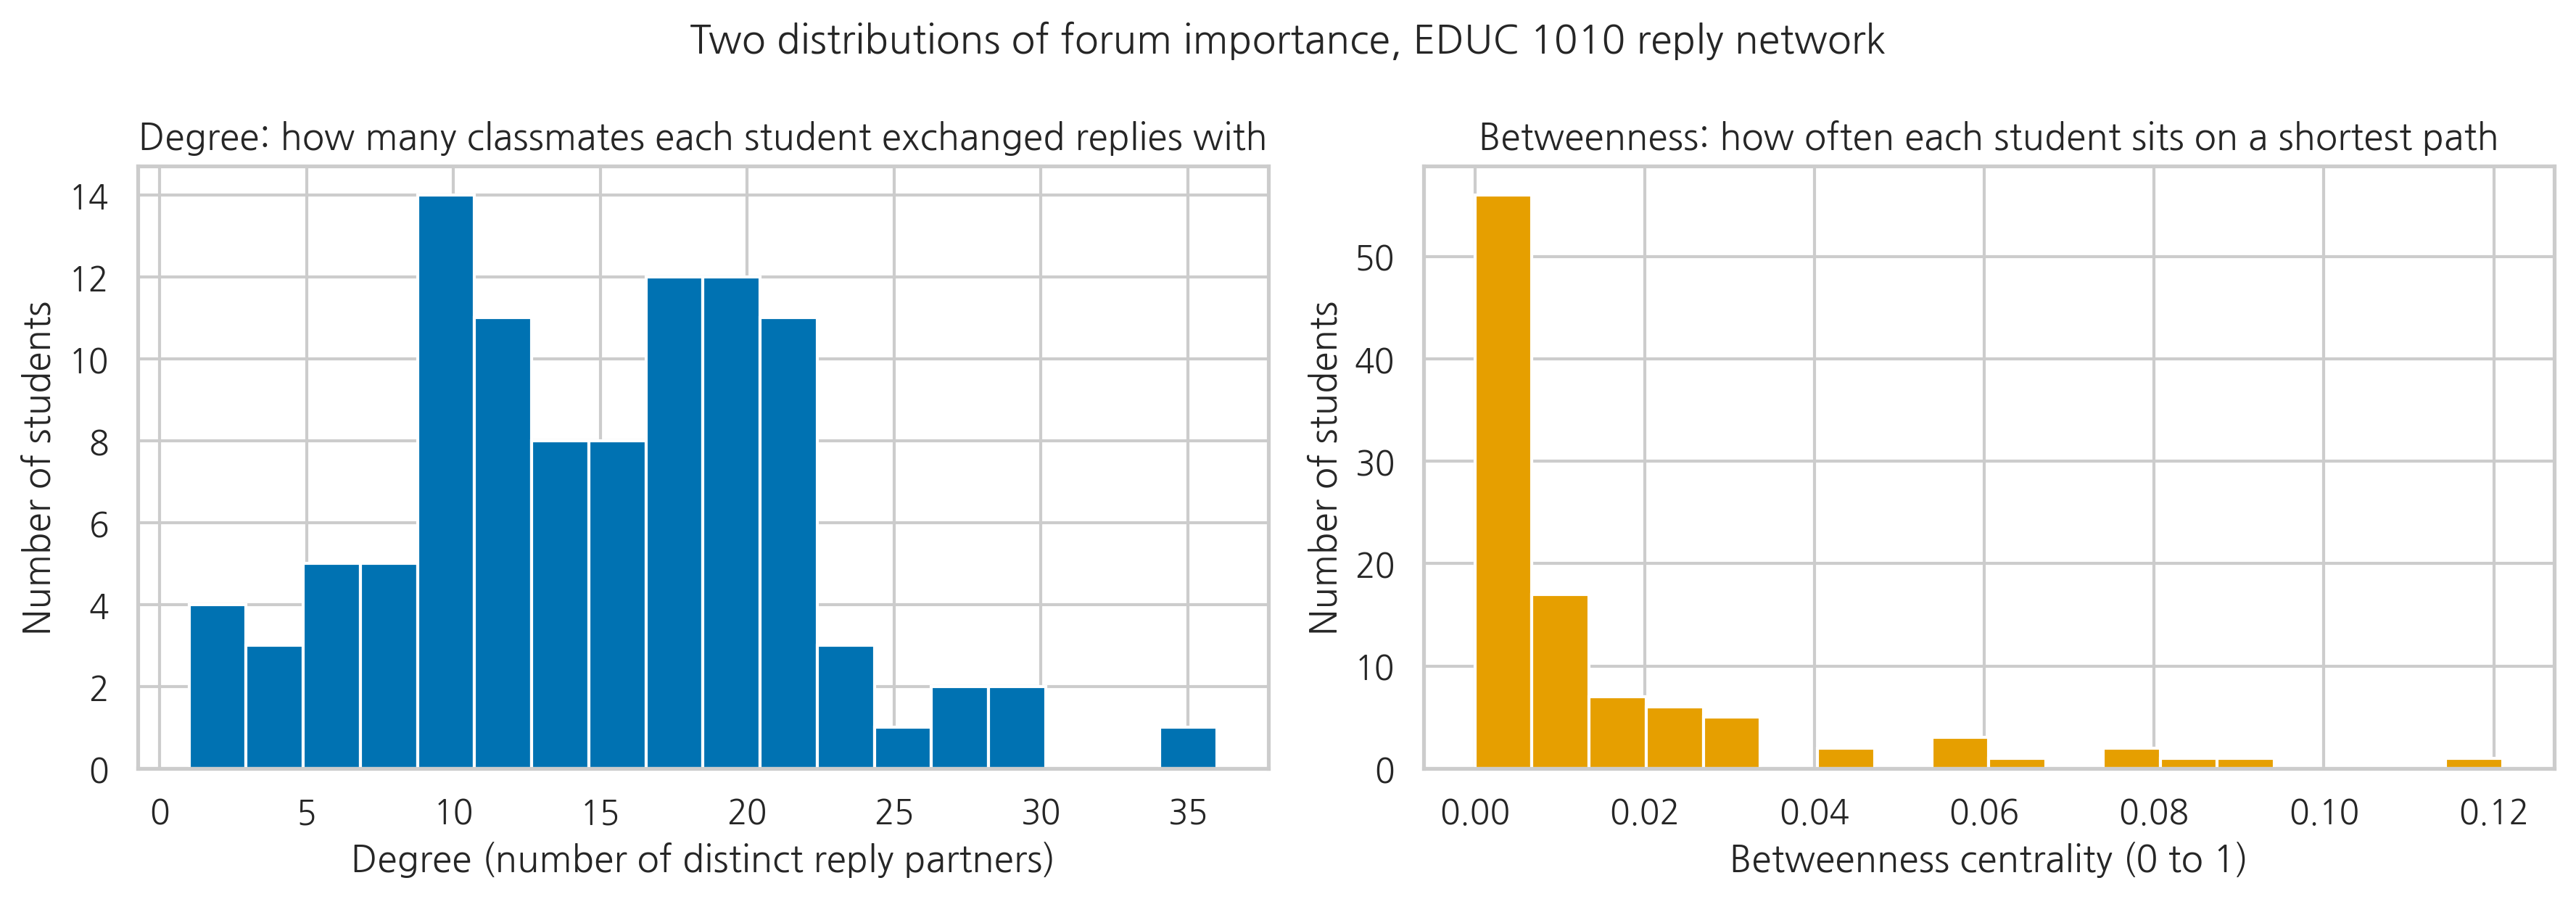

Top 8 by degree:
student_id  degree  betweenness  betweenness_pct
      S039      36     0.121073            100.0
      S002      29     0.057132             93.0
      S087      29     0.010613             66.0
      S057      28     0.046246             90.0
      S065      27     0.088723             99.0
      S045      25     0.021972             80.0
      S072      24     0.033462             89.0
      S076      24     0.046325             91.0

Top 8 by betweenness:
student_id  degree  degree_pct  betweenness
      S039      36       100.0     0.121073
      S065      27        96.0     0.088723
      S020      18        65.0     0.082370
      S043      19        72.0     0.075978
      S101      17        59.0     0.075393
      S075      22        88.0     0.065737
      S031      15        52.0     0.059042
      S002      29        99.0     0.057132


In [6]:
degree      = dict(G.degree())
betweenness = nx.betweenness_centrality(G)          # normalized to 0 to 1
strength    = dict(G.degree(weight='weight'))       # ties, counting repeats

cent = pd.DataFrame({'student_id': sorted(G.nodes())})
cent['degree']      = cent['student_id'].map(degree)
cent['strength']    = cent['student_id'].map(strength)
cent['betweenness'] = cent['student_id'].map(betweenness)
cent['degree_pct']      = (cent['degree'].rank(pct=True) * 100).round(0)
cent['betweenness_pct'] = (cent['betweenness'].rank(pct=True) * 100).round(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(cent['degree'], bins=18, color=BLUE, edgecolor='white')
axes[0].set_title('Degree: how many classmates each student exchanged replies with')
axes[0].set_xlabel('Degree (number of distinct reply partners)')
axes[0].set_ylabel('Number of students')

axes[1].hist(cent['betweenness'], bins=18, color=ORANGE, edgecolor='white')
axes[1].set_title('Betweenness: how often each student sits on a shortest path')
axes[1].set_xlabel('Betweenness centrality (0 to 1)')
axes[1].set_ylabel('Number of students')

fig.suptitle('Two distributions of forum importance, EDUC 1010 reply network', fontsize=13)
fig.tight_layout()
plt.show()

print('Top 8 by degree:')
print(cent.nlargest(8, 'degree')[['student_id', 'degree', 'betweenness', 'betweenness_pct']].to_string(index=False))
print()
print('Top 8 by betweenness:')
print(cent.nlargest(8, 'betweenness')[['student_id', 'degree', 'degree_pct', 'betweenness']].to_string(index=False))

**💬 Interpretation prompt.** Compare the two top-8 lists. Some names appear on both. Some appear on only one.
Pick one student who ranks high on betweenness but sits nowhere near the top on degree, and write a sentence
predicting what their position in the forum looks like. You are about to find out whether you were right.

## 1.5 Putting the two measures on one picture

A table of ranks makes it easy to miss the students who are interesting *because* their two ranks disagree.
A scatterplot makes that disagreement visible: degree on the horizontal axis, betweenness on the vertical.

The reference lines mark the class median degree and the 90th percentile of betweenness. The upper-left region
(unremarkable degree, unusually high betweenness) is where the interesting people live. The upper-right region
holds the students who are central simply because they are everywhere, which is a different phenomenon and
worth less of your attention than it usually gets.

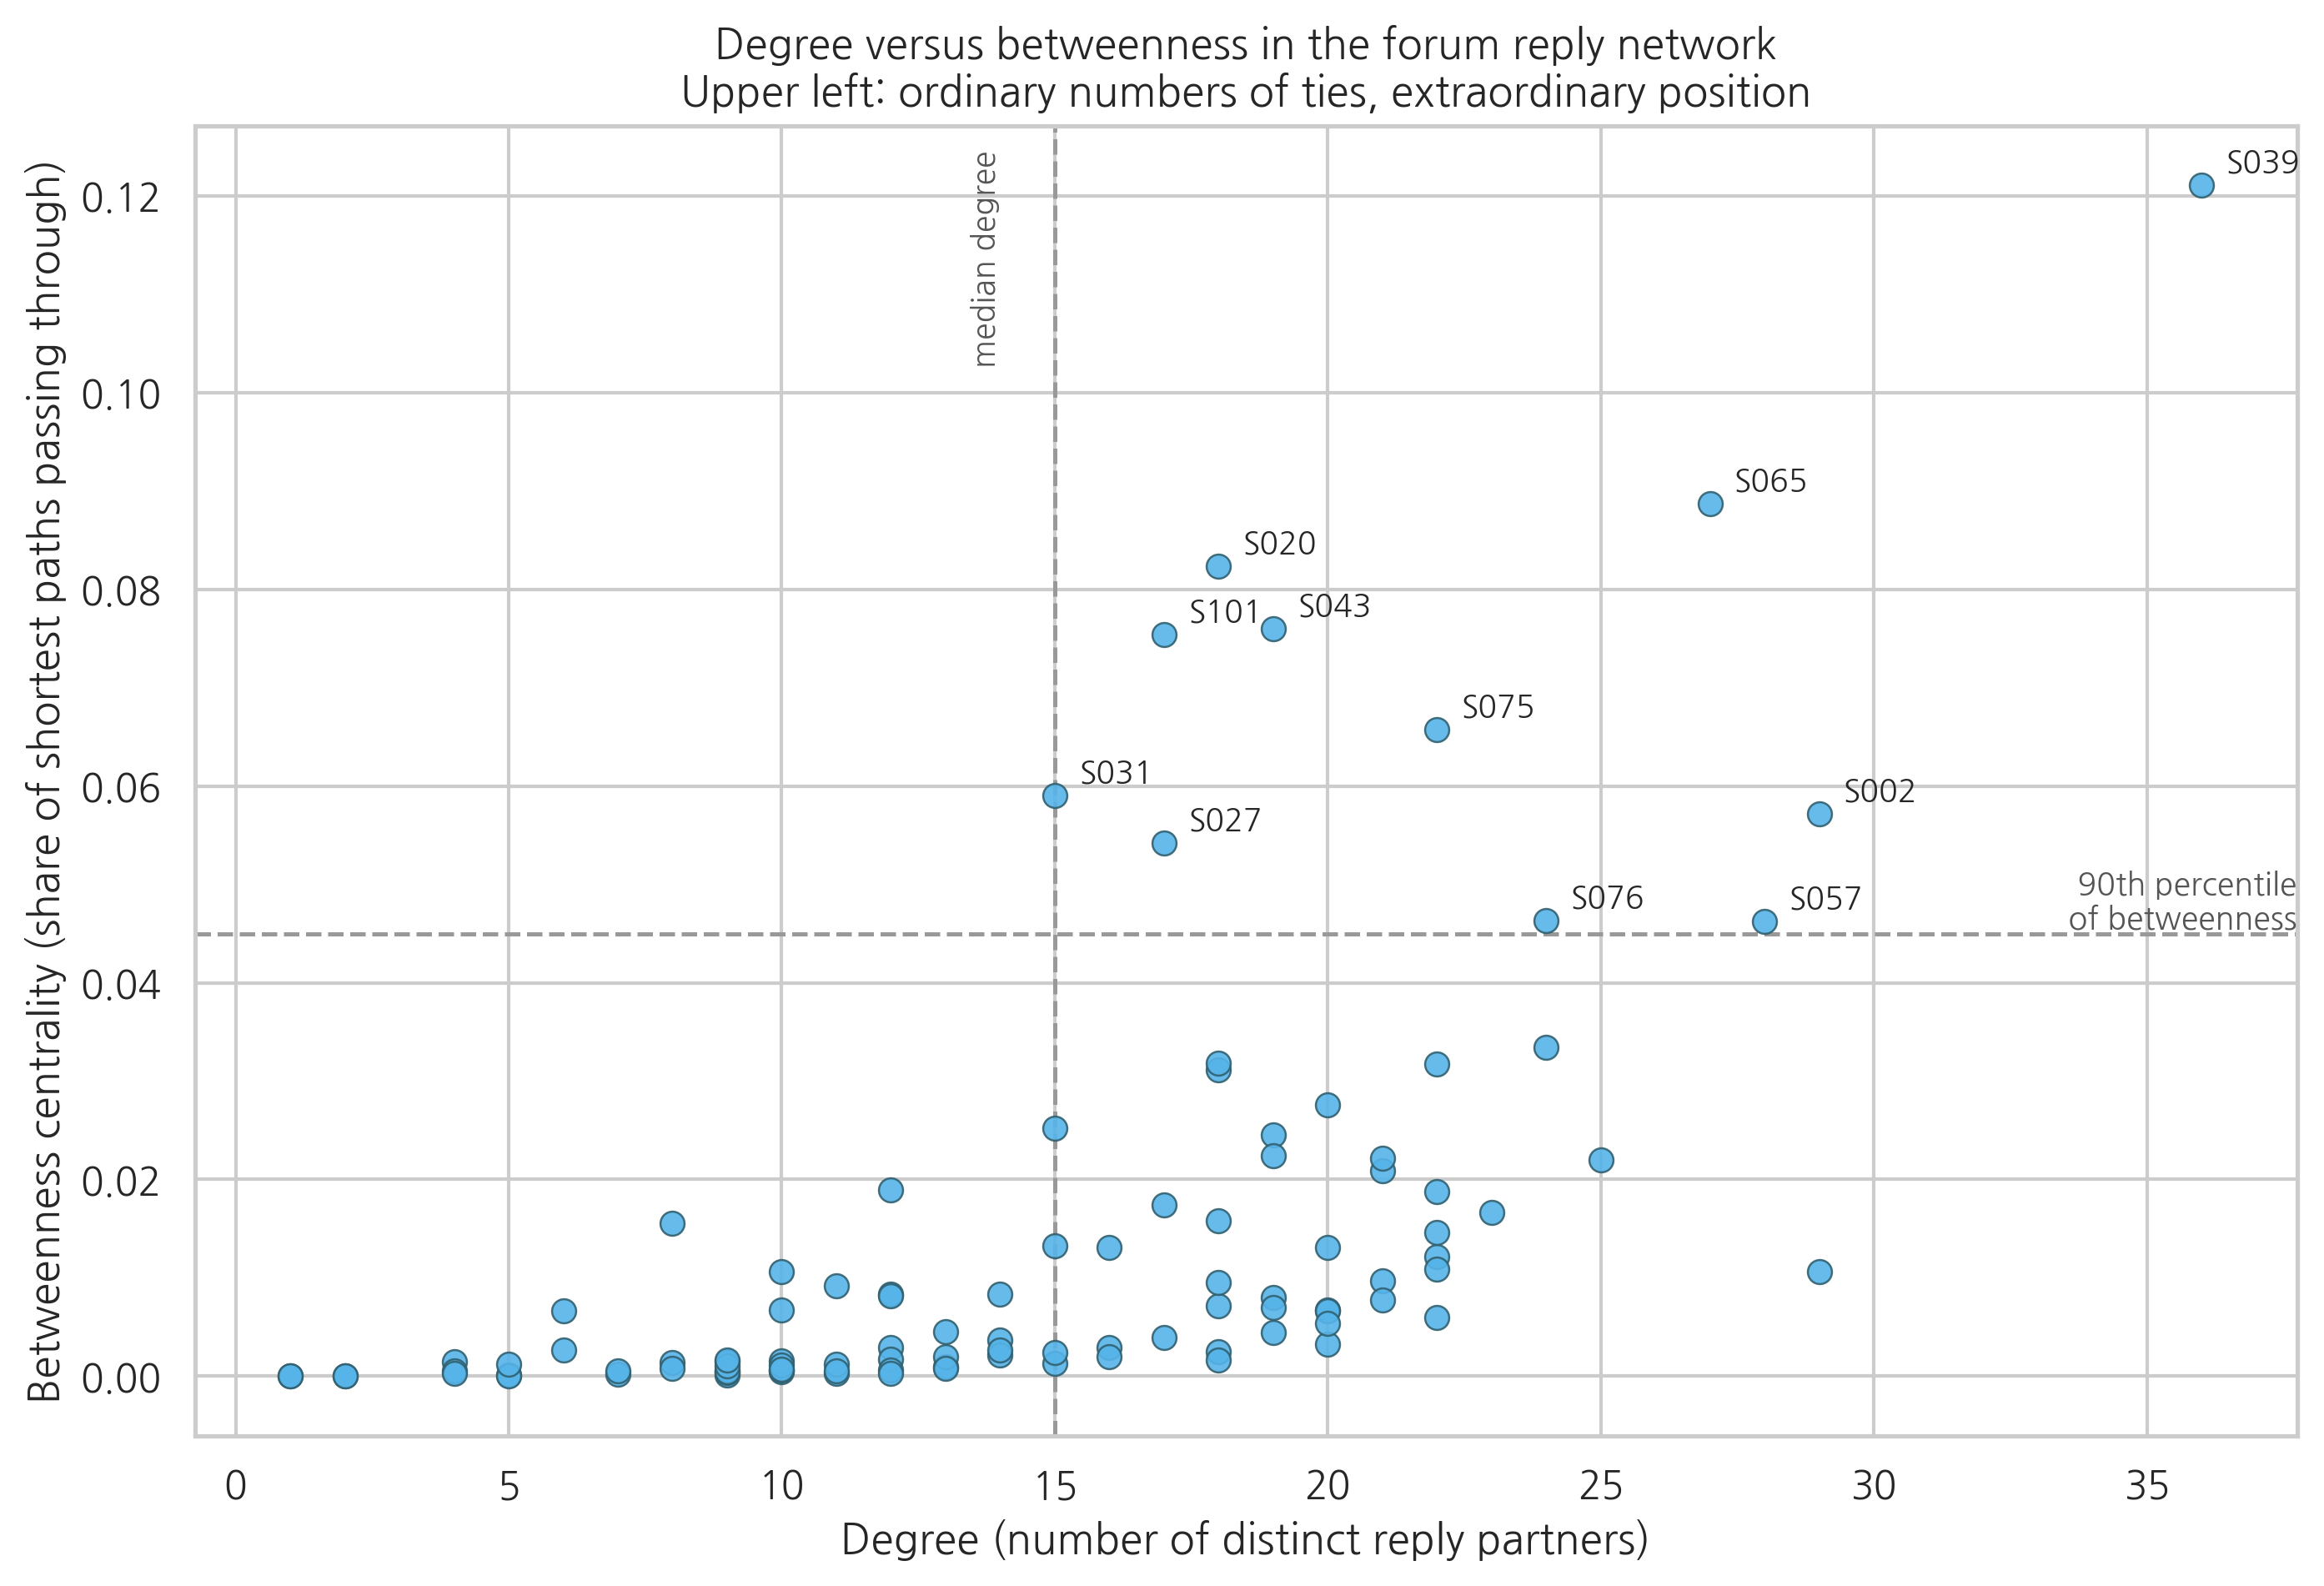

Students with top-10 percent betweenness but no more than the 75th percentile of degree:
student_id  degree  degree_pct  betweenness  betweenness_pct
      S020      18        65.0     0.082370             98.0
      S043      19        72.0     0.075978             97.0
      S101      17        59.0     0.075393             96.0
      S031      15        52.0     0.059042             94.0
      S027      17        59.0     0.054169             92.0


In [7]:
deg_median = cent['degree'].median()
btw_p90    = cent['betweenness'].quantile(0.90)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.scatter(cent['degree'], cent['betweenness'], s=48, color=SKY,
           edgecolor='#31606f', linewidth=0.6, alpha=0.9, zorder=3)

ax.axvline(deg_median, color=GRAY, linestyle='--', linewidth=1.2, zorder=2)
ax.axhline(btw_p90, color=GRAY, linestyle='--', linewidth=1.2, zorder=2)

# Label everyone above the betweenness cut so the shortlist is readable.
for row in cent[cent['betweenness'] >= btw_p90].itertuples(index=False):
    ax.annotate(row.student_id, (row.degree, row.betweenness),
                textcoords='offset points', xytext=(7, 4), fontsize=9)

ax.text(deg_median - 1, ax.get_ylim()[1] * 0.98, 'median degree',
        rotation=90, ha='right', va='top', fontsize=9, color='#555555')
ax.text(ax.get_xlim()[1], btw_p90, ' 90th percentile\n of betweenness',
        ha='right', va='bottom', fontsize=9, color='#555555')

ax.set_title('Degree versus betweenness in the forum reply network\n'
             'Upper left: ordinary numbers of ties, extraordinary position')
ax.set_xlabel('Degree (number of distinct reply partners)')
ax.set_ylabel('Betweenness centrality (share of shortest paths passing through)')
fig.tight_layout()
plt.show()

shortlist = cent[(cent['betweenness'] >= btw_p90) & (cent['degree'] <= cent['degree'].quantile(0.75))]
print('Students with top-10 percent betweenness but no more than the 75th percentile of degree:')
print(shortlist[['student_id', 'degree', 'degree_pct', 'betweenness', 'betweenness_pct']]
      .sort_values('betweenness', ascending=False).to_string(index=False))

**💬 Interpretation prompt.** The scatterplot has given you a shortlist, not an answer. Two of the highest
betweenness students in the class sit at the far right of the plot: they are on many shortest paths because
they are attached to almost everyone, which is not the same thing as bridging. Before you read on, write down
what evidence would convince you that a particular student is a **bridge** rather than a **hub**.

## 1.6 Finding the communities

To talk about bridging we need something to bridge. Community detection partitions the graph so that ties are
dense inside groups and sparse between them. We use greedy modularity optimization (Clauset, Newman, and Moore),
which is available directly in `networkx` and is deterministic, so your result will match your neighbor's.

**Modularity** is the quality score: roughly, how much more within-group connection there is than you would
expect if the same students had wired themselves at random. Values above about 0.3 are usually taken as real
structure. Nothing here tells you *why* the groups exist, and modularity will happily hand you communities in a
graph that has none, which is why the number matters.

In [8]:
communities = nx.community.greedy_modularity_communities(G, weight='weight')
community_of = {node: i for i, group in enumerate(communities) for node in group}
cent['community'] = cent['student_id'].map(community_of)

Q = nx.community.modularity(G, communities, weight='weight')
print('Communities found :', len(communities))
print('Modularity (Q)    :', round(Q, 3))
print()
print(cent.groupby('community')
          .agg(students=('student_id', 'size'),
               mean_degree=('degree', 'mean'),
               mean_betweenness=('betweenness', 'mean'))
          .round(3).to_string())

within  = sum(1 for a, b in G.edges() if community_of[a] == community_of[b])
across  = G.number_of_edges() - within
print()
print('Ties inside a community :', within)
print('Ties across communities :', across,
      '(' + str(round(100 * across / G.number_of_edges(), 1)) + ' percent of all ties)')

Communities found : 3
Modularity (Q)    : 0.612

           students  mean_degree  mean_betweenness
community                                         
0                36       16.722             0.014
1                34       13.382             0.016
2                32       13.969             0.013

Ties inside a community : 700
Ties across communities : 52 (6.9 percent of all ties)


## 1.7 Bridges, not hubs

Now we can separate the two kinds of importance cleanly. For each student, compute the share of their ties that
leave their own community:

`bridge_share = ties to other communities / total ties`

A hub has hundreds of ties and almost all of them are local, so its bridge share is low. A bridge has an
ordinary number of ties and an unusual share of them cross a boundary. We require at least a handful of ties
(`MIN_DEGREE`) so that a student with two ties, one of which happens to cross, does not top the list by
accident.

Connectors found: 4
student_id  community  degree  degree_pct  ties_across  bridge_share  betweenness  betweenness_pct
      S020          1      18        65.0           14         0.778        0.082             98.0
      S101          0      17        59.0            9         0.529        0.075             96.0
      S031          0      15        52.0            7         0.467        0.059             94.0
      S043          1      19        72.0            8         0.421        0.076             97.0


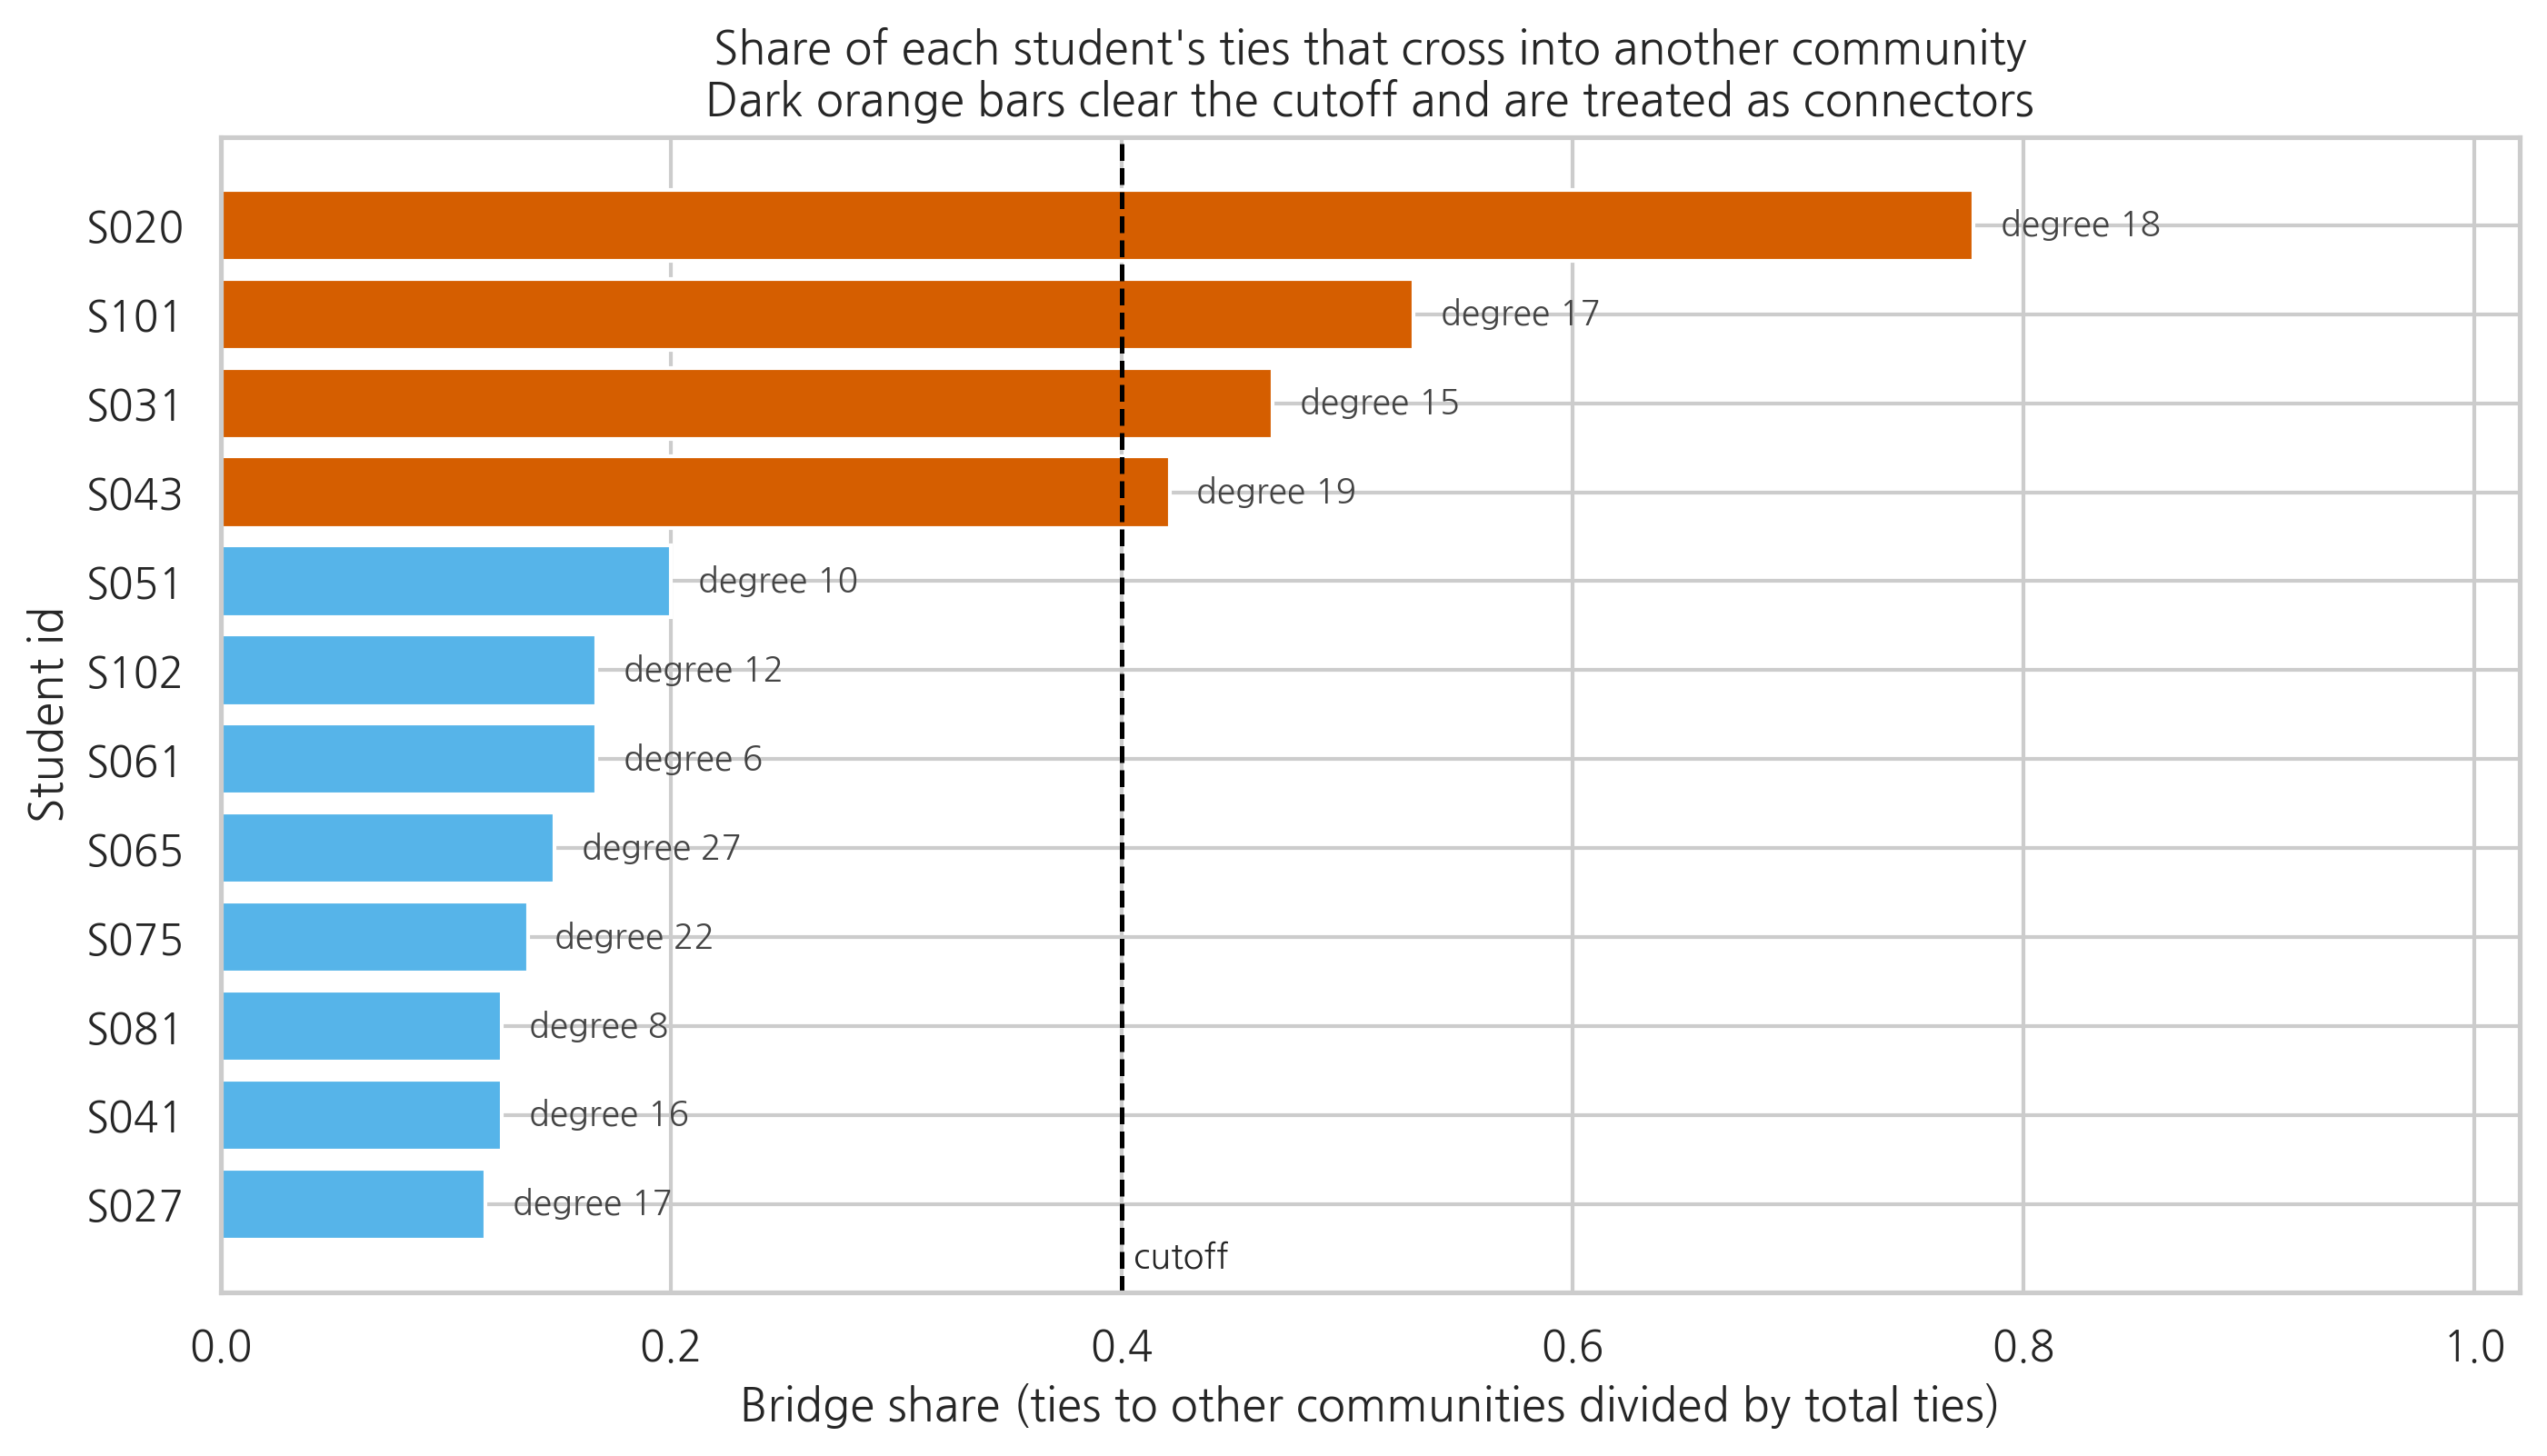

In [9]:
MIN_DEGREE    = 5      # ignore students with too few ties for the share to mean anything
BRIDGE_CUTOFF = 0.40   # a student is a connector if at least this share of their ties cross a community line

external = {n: sum(1 for m in G[n] if community_of[m] != community_of[n]) for n in G.nodes()}
cent['ties_across']  = cent['student_id'].map(external)
cent['bridge_share'] = cent['ties_across'] / cent['degree']

eligible  = cent[cent['degree'] >= MIN_DEGREE].copy()
connectors = (eligible[eligible['bridge_share'] >= BRIDGE_CUTOFF]
              .sort_values('bridge_share', ascending=False))

print('Connectors found:', len(connectors))
print(connectors[['student_id', 'community', 'degree', 'degree_pct',
                  'ties_across', 'bridge_share', 'betweenness', 'betweenness_pct']]
      .round(3).to_string(index=False))

connector_ids = connectors['student_id'].tolist()

top12 = eligible.nlargest(12, 'bridge_share').sort_values('bridge_share')
colors = [VERMILLION if s in connector_ids else SKY for s in top12['student_id']]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.barh(top12['student_id'], top12['bridge_share'], color=colors, edgecolor='white')
for bar, deg in zip(bars, top12['degree']):
    ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2,
            'degree ' + str(int(deg)), va='center', fontsize=9, color='#444444')
ax.axvline(BRIDGE_CUTOFF, color='black', linestyle='--', linewidth=1.2)
ax.text(BRIDGE_CUTOFF + 0.005, -0.7, 'cutoff', fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_title('Share of each student\'s ties that cross into another community\n'
             'Dark orange bars clear the cutoff and are treated as connectors')
ax.set_xlabel('Bridge share (ties to other communities divided by total ties)')
ax.set_ylabel('Student id')
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Look at the gap in the bar chart. There is a cluster of students far above the
cutoff and then a long drop, which means the cutoff value is doing much less work than it might appear. Compare
these students' degree percentiles against their betweenness percentiles in the printed table. Would any
dashboard you have seen this semester (including the one you built in Mini Project 1) have surfaced these
students? What would this forum look like in week 9 if all of them stopped posting?

## 1.8 The sociogram

Now draw it. A sociogram is just the graph with a layout: `spring_layout` treats edges as springs and pushes
unconnected nodes apart, so densely tied groups end up near each other. The layout has no units and no axes.
Position means nothing except relative connection, which is why we label the picture carefully instead of
inviting people to read distances off it.

Reading aids in this figure: node color is community, node size is degree, faint gray lines are ties inside a
community, heavy black lines are ties that cross between communities, and the ringed and labeled nodes are the
connectors we identified above.

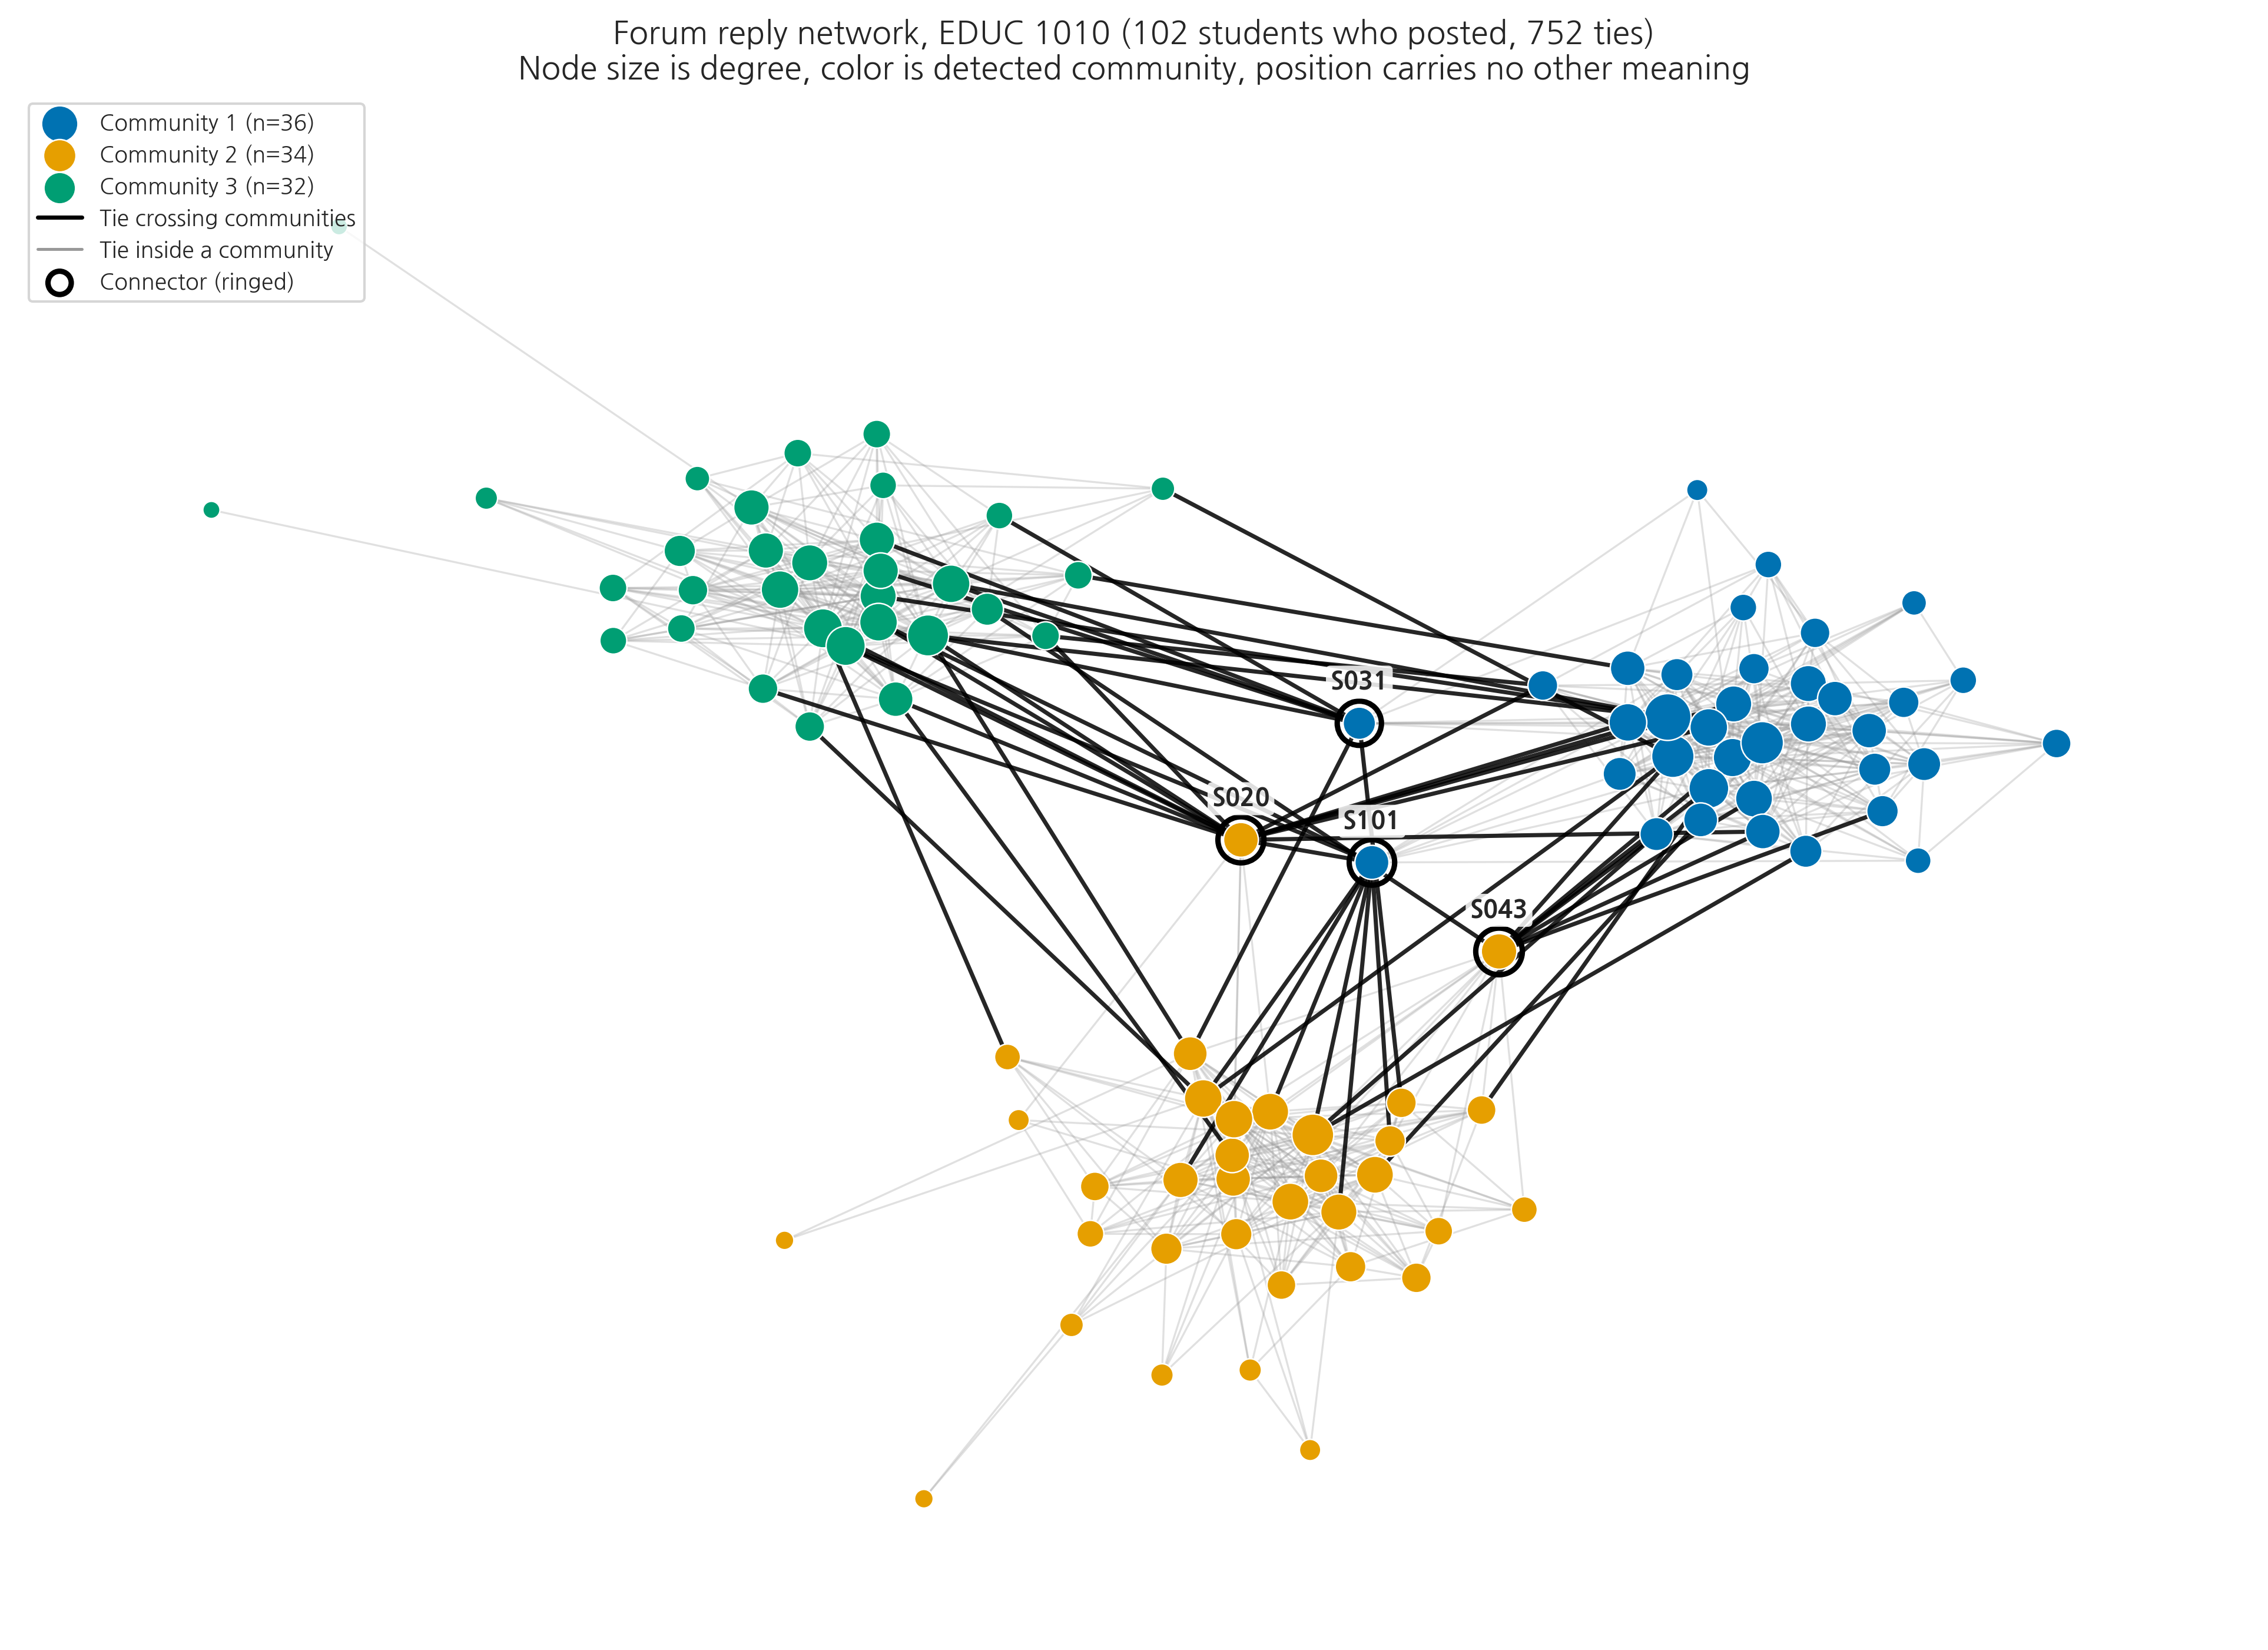

In [10]:
pos = nx.spring_layout(G, seed=8100, k=0.55, iterations=200, weight='weight')

within_edges = [(a, b) for a, b in G.edges() if community_of[a] == community_of[b]]
across_edges = [(a, b) for a, b in G.edges() if community_of[a] != community_of[b]]

fig, ax = plt.subplots(figsize=(13, 9.5))
nx.draw_networkx_edges(G, pos, edgelist=within_edges, ax=ax,
                       edge_color=GRAY, width=0.8, alpha=0.30)
nx.draw_networkx_edges(G, pos, edgelist=across_edges, ax=ax,
                       edge_color='black', width=1.7, alpha=0.85)

for i, group in enumerate(communities):
    nodes = sorted(group)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax,
                           node_size=[40 + 9 * degree[n] for n in nodes],
                           node_color=CLUSTER_COLORS[i % len(CLUSTER_COLORS)],
                           edgecolors='white', linewidths=0.6,
                           label='Community ' + str(i + 1) + ' (n=' + str(len(nodes)) + ')')

nx.draw_networkx_nodes(G, pos, nodelist=connector_ids, ax=ax,
                       node_size=[190 + 9 * degree[n] for n in connector_ids],
                       node_color='none', edgecolors='black', linewidths=2.2)

for n in connector_ids:
    ax.annotate(n, (pos[n][0], pos[n][1]), textcoords='offset points', xytext=(0, 14),
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.85))

ax.plot([], [], color='black', linewidth=1.7, label='Tie crossing communities')
ax.plot([], [], color=GRAY, linewidth=1.2, label='Tie inside a community')
ax.scatter([], [], s=90, facecolor='none', edgecolor='black', linewidth=2.2, label='Connector (ringed)')
ax.legend(loc='upper left', fontsize=9, frameon=True)

ax.set_title('Forum reply network, EDUC 1010 (' + str(G.number_of_nodes()) + ' students who posted, '
             + str(G.number_of_edges()) + ' ties)\n'
             'Node size is degree, color is detected community, position carries no other meaning',
             fontsize=13)
ax.axis('off')
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Answer three questions in a sentence each.

1. The ringed students sit in the middle of the picture. Are they in the middle because they are popular, or
   because of something else? Use the numbers from section 1.7, not the picture, to defend your answer.
2. One hundred and two nodes are drawn here. One hundred and twenty students are enrolled. Where are the other
   eighteen in this figure, and what would you have to say in a memo to keep a reader from forgetting them?
3. Poquet and Joksimovic (2022) call the field a "cacophony of networks" partly because the same students
   produce a different graph depending on what you count as a tie. Name one other tie definition you could have
   used with this dataset, and say who would gain or lose visibility under it.

## ✏️ Your turn 1: move the connector thresholds

The two numbers below decided who counted as a connector. They are judgment calls, not discoveries, and part of
doing this well is knowing how fragile your finding is when you move them.

Change `MY_MIN_DEGREE` and `MY_BRIDGE_CUTOFF`, then run the cell. Try a cutoff of `0.25` and watch how many
students qualify. Try `MY_MIN_DEGREE = 2` and see who a low bar lets in.

In [11]:
# TODO: change one or both of these numbers, then run the cell.
MY_MIN_DEGREE    = 5      # working default
MY_BRIDGE_CUTOFF = 0.40   # working default

my_pool = cent[cent['degree'] >= MY_MIN_DEGREE]
my_connectors = (my_pool[my_pool['bridge_share'] >= MY_BRIDGE_CUTOFF]
                 .sort_values('bridge_share', ascending=False))

print('With min degree', MY_MIN_DEGREE, 'and cutoff', MY_BRIDGE_CUTOFF,
      'the connector list has', len(my_connectors), 'students:')
print(my_connectors[['student_id', 'degree', 'ties_across', 'bridge_share', 'betweenness']]
      .round(3).to_string(index=False))

With min degree 5 and cutoff 0.4 the connector list has 4 students:
student_id  degree  ties_across  bridge_share  betweenness
      S020      18           14         0.778        0.082
      S101      17            9         0.529        0.075
      S031      15            7         0.467        0.059
      S043      19            8         0.421        0.076


## ✏️ Your turn 2: one week at a time

The network above pools all eight weeks, which quietly assumes that a reply in week 1 and a reply in week 8
mean the same thing and belong in the same picture. Molenaar and Wise (2022) would call that an assumption
about time worth stating out loud.

Change `WEEK_TO_INSPECT` to any week from 1 to 8 and rerun. Notice how much thinner a single week is, and how
much less stable the centrality ranking becomes when it rests on fewer ties.

In [12]:
# TODO: change this to any week from 1 to 8.
WEEK_TO_INSPECT = 3   # working default

week_posts = forum[forum['week'] == WEEK_TO_INSPECT]
G_week = build_reply_network(week_posts)

print('Week', WEEK_TO_INSPECT, ': posts =', len(week_posts),
      '| students in network =', G_week.number_of_nodes(),
      '| ties =', G_week.number_of_edges(),
      '| density =', round(nx.density(G_week), 3),
      '| components =', nx.number_connected_components(G_week))

week_btw = nx.betweenness_centrality(G_week)
week_tab = (pd.DataFrame({'student_id': list(week_btw), 'betweenness': list(week_btw.values())})
            .assign(degree=lambda d: d['student_id'].map(dict(G_week.degree())))
            .nlargest(5, 'betweenness'))
print()
print('Top 5 by betweenness in week', str(WEEK_TO_INSPECT) + ':')
print(week_tab.round(3).to_string(index=False))

Week 3 : posts = 177 | students in network = 74 | ties = 147 | density = 0.054 | components = 1

Top 5 by betweenness in week 3:
student_id  betweenness  degree
      S084        0.347       6
      S067        0.308       4
      S082        0.235       4
      S040        0.233       8
      S043        0.225       3


---

# Part 2. ⏱️ Time, order, and the shape of a semester

In week 1 we opened with two students who had the same summary number and completely different realities. The
missing piece then was **context**: the number could not tell you what was going on around it.

This half is about a second kind of missing piece: **order**. A total says how much. It says nothing about
when, in what rhythm, or in what sequence. Two students can generate the same count of anything and have lived
different semesters, and the difference is often the part that matters.

## 2.1 How long before the deadline did work arrive?

`gradebook.csv` gives us both `submitted_at` and `deadline` for eight quizzes, so we can compute lead time in
hours. Positive means early, negative means late.

The left panel shows the whole distribution. The right panel bins lead time into bands and shows the mean quiz
score in each, with the number of submissions printed above each bar so you can see which bands are thin.

                     submissions  mean_score     sd
timing_band                                        
After the\ndeadline           33       73.26   9.35
Final 6\nhours               175       68.15  12.02
6 to 24\nhours               270       72.38  12.32
1 to 3\ndays                 257       78.14  11.61
More than\n3 days            225       83.28  11.78

Share of quiz submissions arriving in the final 6 hours: 18.2 percent
Mean score, final 6 hours : 68.15 (n = 175)
Mean score, earlier       : 77.61 (n = 752)
Cohen's d                 : -0.75


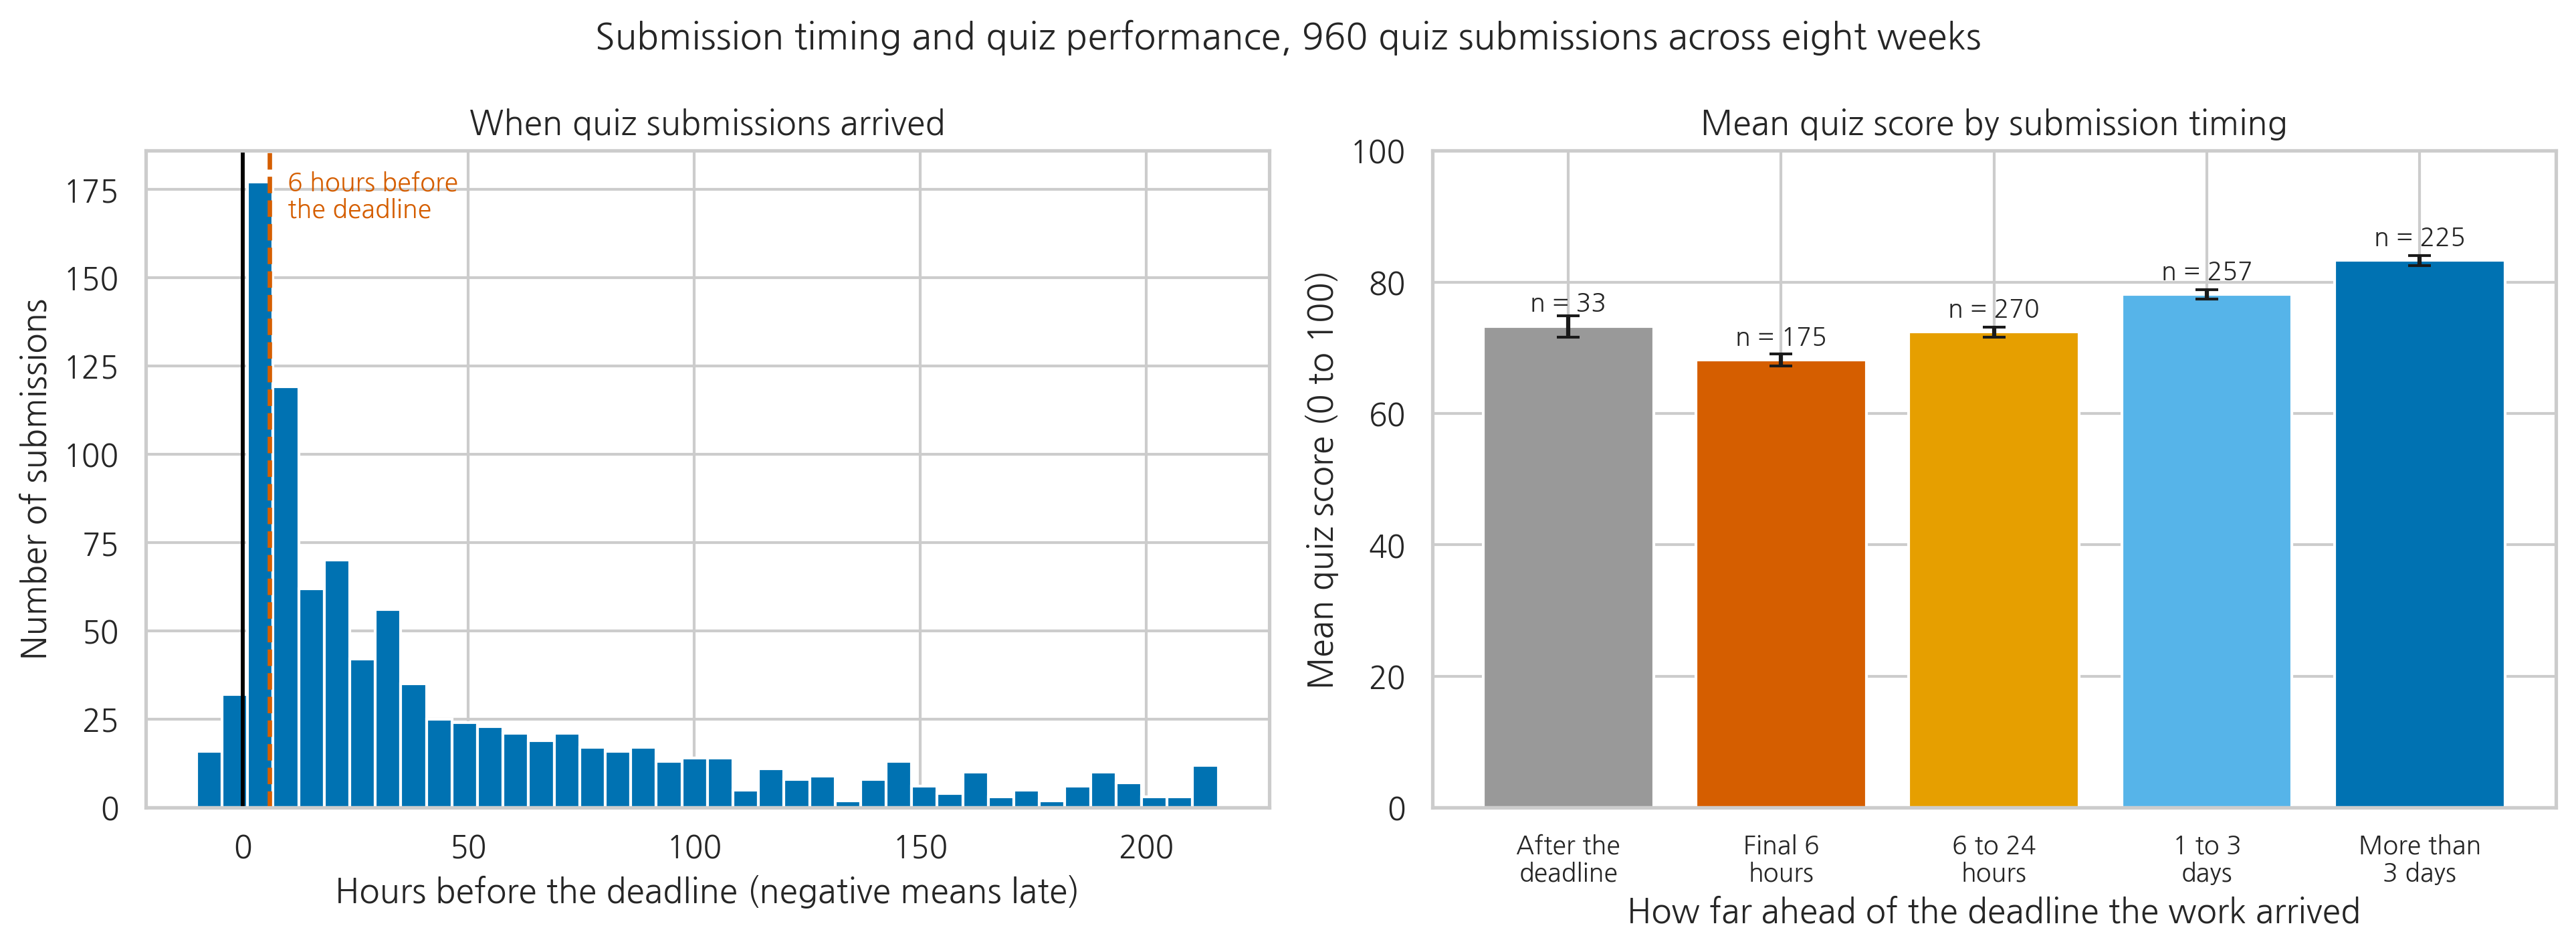

In [13]:
quizzes = grades[grades['assessment'].str.startswith('quiz')].copy()
quizzes['lead_hours'] = (quizzes['deadline'] - quizzes['submitted_at']).dt.total_seconds() / 3600

LAST_MINUTE_HOURS = 6
bands  = [-np.inf, 0, LAST_MINUTE_HOURS, 24, 72, np.inf]
labels = ['After the\ndeadline', 'Final 6\nhours', '6 to 24\nhours', '1 to 3\ndays', 'More than\n3 days']
quizzes['timing_band'] = pd.cut(quizzes['lead_hours'], bins=bands, labels=labels)

by_band = (quizzes.groupby('timing_band', observed=False)
           .agg(submissions=('score', 'size'), mean_score=('score', 'mean'), sd=('score', 'std'))
           .round(2))
print(by_band.to_string())

late_share = ((quizzes['lead_hours'] >= 0) & (quizzes['lead_hours'] <= LAST_MINUTE_HOURS)).mean()
print()
print('Share of quiz submissions arriving in the final', LAST_MINUTE_HOURS, 'hours:',
      str(round(100 * late_share, 1)) + ' percent')

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled

last_minute = quizzes.loc[quizzes['lead_hours'].between(0, LAST_MINUTE_HOURS), 'score']
earlier     = quizzes.loc[quizzes['lead_hours'] > LAST_MINUTE_HOURS, 'score']
print('Mean score, final 6 hours :', round(last_minute.mean(), 2), '(n =', str(len(last_minute)) + ')')
print('Mean score, earlier       :', round(earlier.mean(), 2), '(n =', str(len(earlier)) + ')')
print("Cohen's d                 :", round(cohens_d(last_minute, earlier), 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(quizzes['lead_hours'].clip(-24, 216), bins=40, color=BLUE, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1.4)
axes[0].axvline(LAST_MINUTE_HOURS, color=VERMILLION, linestyle='--', linewidth=1.6)
axes[0].text(LAST_MINUTE_HOURS + 4, axes[0].get_ylim()[1] * 0.9, '6 hours before\nthe deadline',
             fontsize=9, color=VERMILLION)
axes[0].set_title('When quiz submissions arrived')
axes[0].set_xlabel('Hours before the deadline (negative means late)')
axes[0].set_ylabel('Number of submissions')

band_colors = [GRAY, VERMILLION, ORANGE, SKY, BLUE]
bars = axes[1].bar(range(len(by_band)), by_band['mean_score'], color=band_colors,
                   yerr=by_band['sd'] / np.sqrt(by_band['submissions']), capsize=4,
                   edgecolor='white')
for i, (bar, n) in enumerate(zip(bars, by_band['submissions'])):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2.4,
                 'n = ' + str(int(n)), ha='center', fontsize=9)
axes[1].set_xticks(range(len(by_band)))
axes[1].set_xticklabels(by_band.index, fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].set_title('Mean quiz score by submission timing')
axes[1].set_xlabel('How far ahead of the deadline the work arrived')
axes[1].set_ylabel('Mean quiz score (0 to 100)')

fig.suptitle('Submission timing and quiz performance, 960 quiz submissions across eight weeks', fontsize=13)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** The gradient across the bars is large: roughly fifteen points between the
earliest and the latest band, and about three quarters of a standard deviation between the final-6-hours group
and everyone else.

Now be careful, because this is where the week costs people their dissertations.

1. Write the causal claim you are tempted to make in one sentence. ("Submitting at the last minute causes ...")
2. Write two other explanations that fit these numbers exactly as well. Hint: what kind of week produces both a
   rushed submission and a lower score, without either one causing the other?
3. Look at the leftmost bar, the submissions that arrived after the deadline. It does not follow the trend. Say
   why that bar might behave differently, and whether it strengthens or weakens your causal story.

## 2.2 From submissions to students

The bar chart pooled 960 submissions, which means one student who submits late every single week counts eight
times. Moving to the student level (one dot per person) tells you whether this is a habit that travels with
people or an occasional bad week that anyone might have.

For each student we compute the share of their eight quizzes submitted in the final six hours, and their mean
quiz score. The line is a simple least squares fit, drawn to show direction and nothing more.

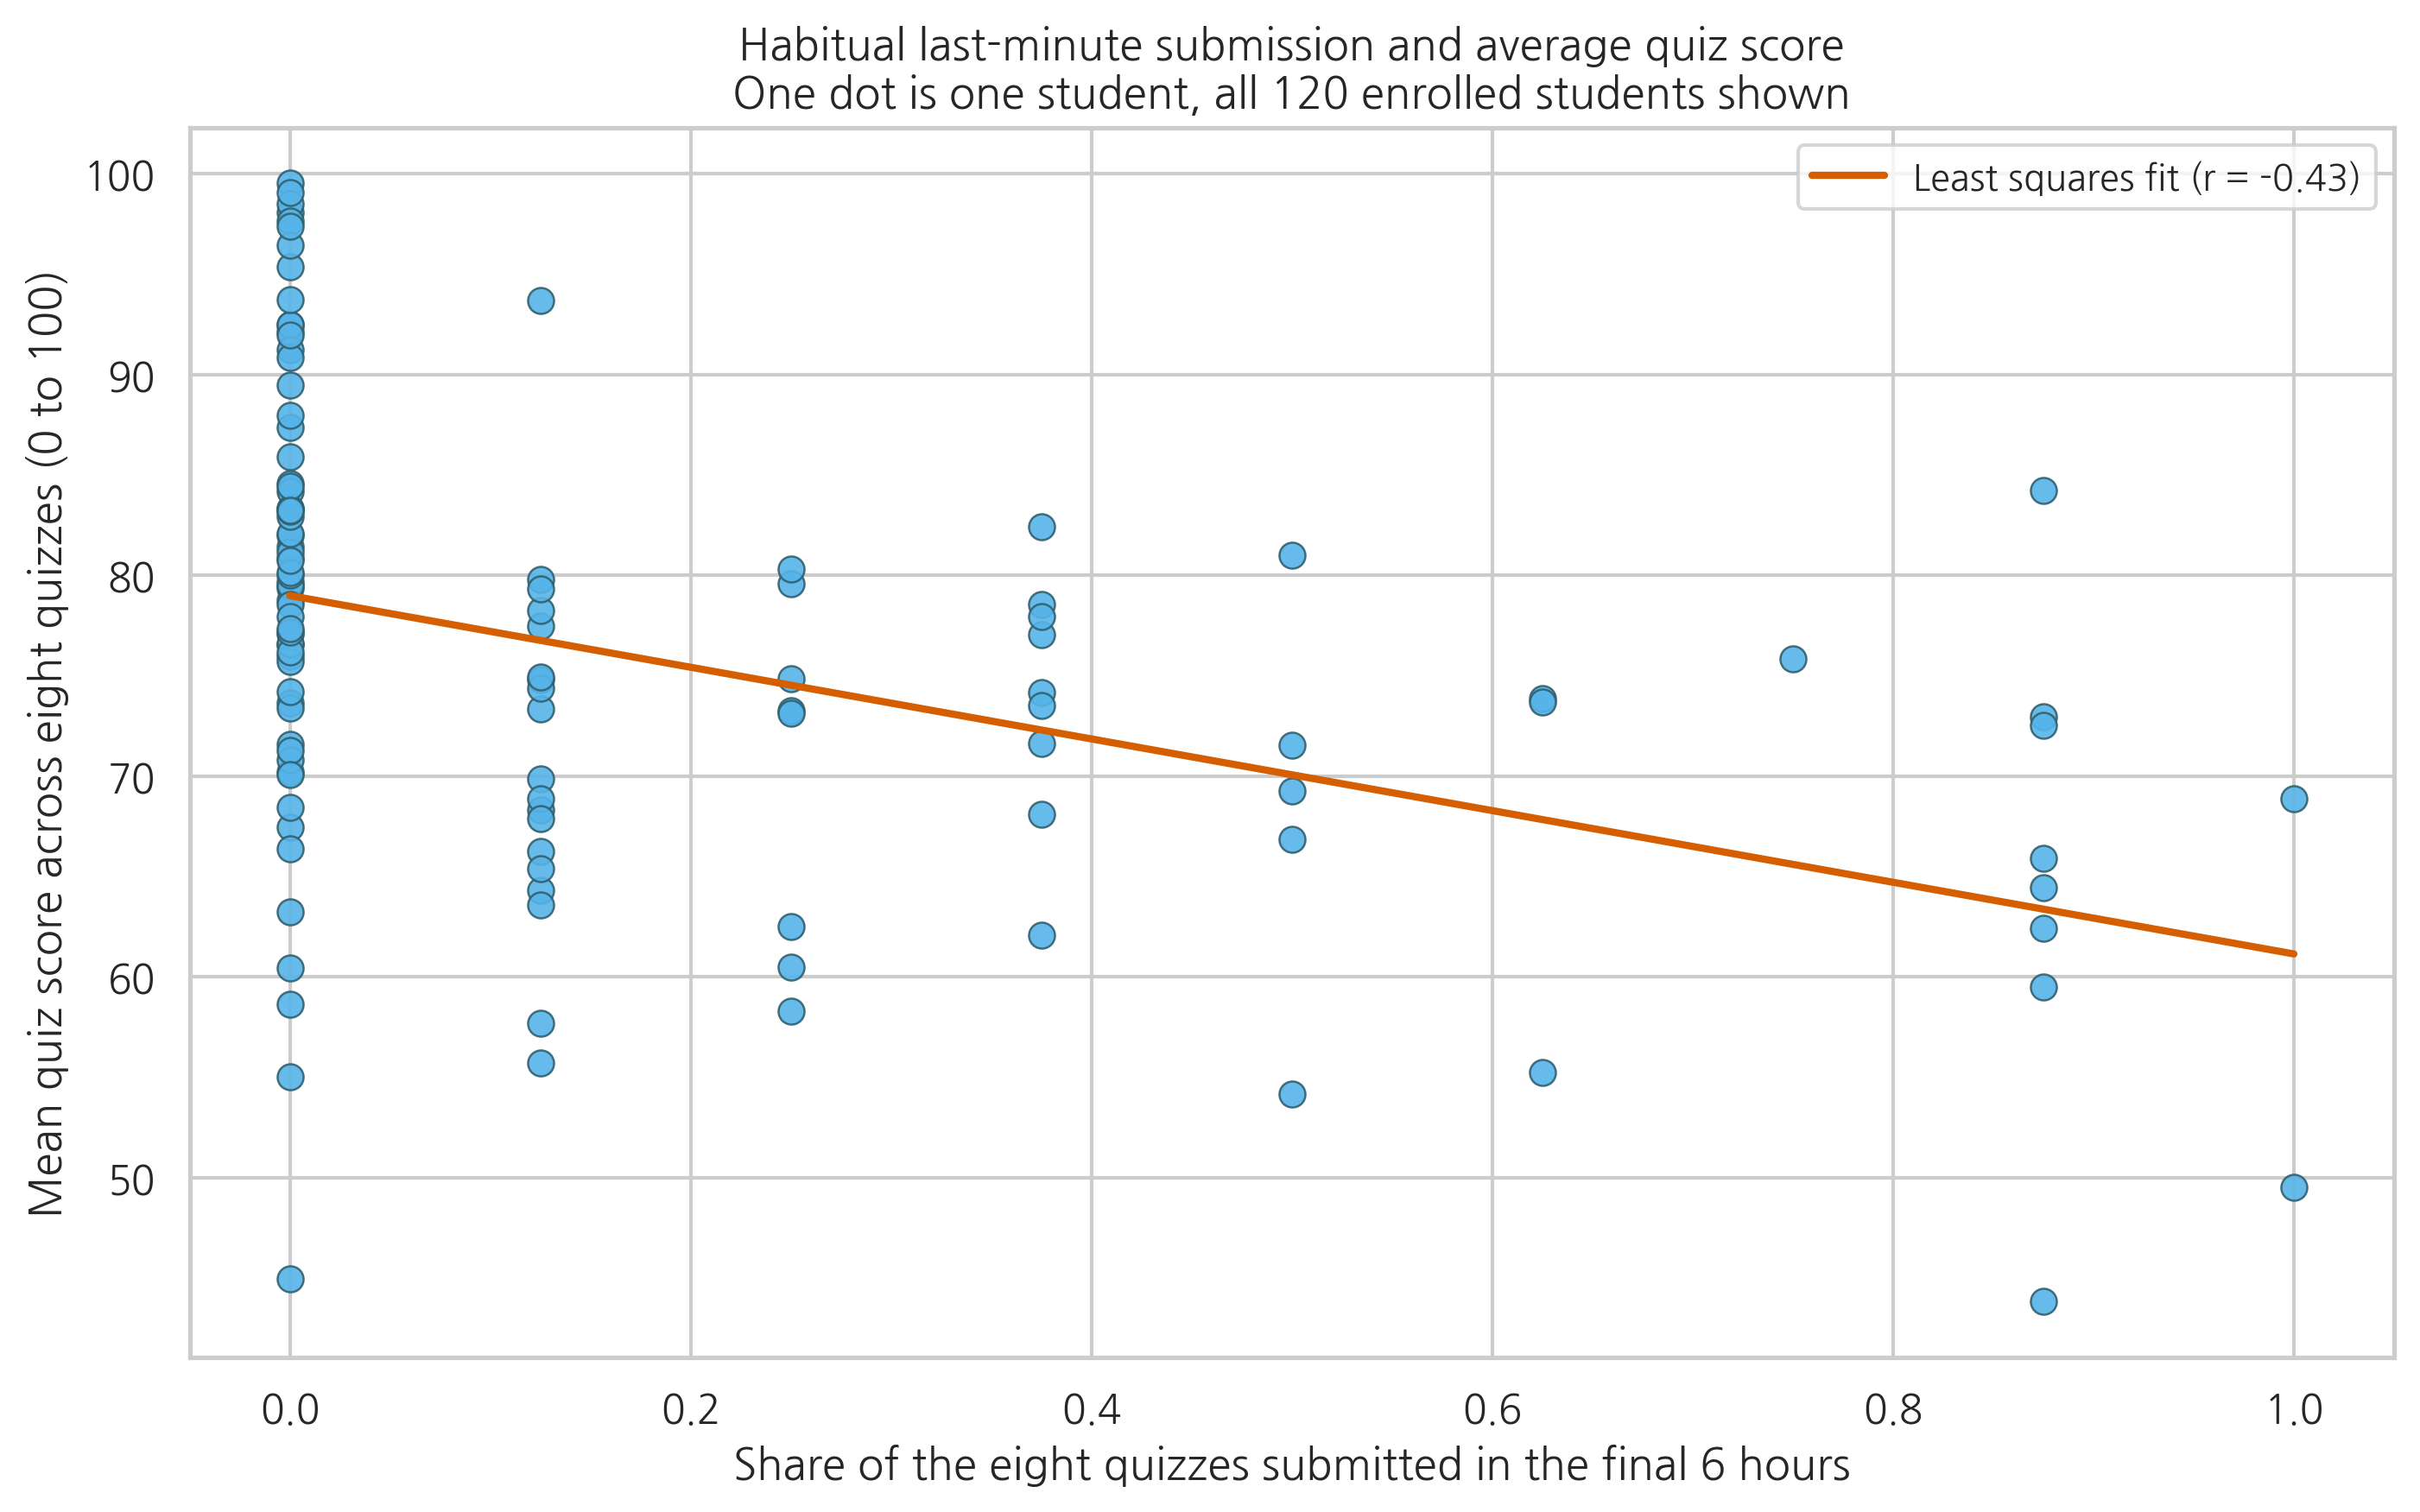

Students who never submitted in the final 6 hours: 65 of 120
Students who did so on at least half their quizzes: 19
Correlation between share last minute and mean score: r = -0.43


In [14]:
per_student = (quizzes.groupby('student_id')
               .agg(mean_score=('score', 'mean'),
                    median_lead_hours=('lead_hours', 'median'),
                    share_last_minute=('lead_hours',
                                       lambda x: ((x >= 0) & (x <= LAST_MINUTE_HOURS)).mean()))
               .reset_index())

r = np.corrcoef(per_student['share_last_minute'], per_student['mean_score'])[0, 1]
slope, intercept = np.polyfit(per_student['share_last_minute'], per_student['mean_score'], 1)
xs = np.linspace(0, 1, 50)

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(per_student['share_last_minute'], per_student['mean_score'],
           s=52, color=SKY, edgecolor='#31606f', linewidth=0.6, alpha=0.9, zorder=3)
ax.plot(xs, intercept + slope * xs, color=VERMILLION, linewidth=2, zorder=4,
        label='Least squares fit (r = ' + str(round(r, 2)) + ')')
ax.set_title('Habitual last-minute submission and average quiz score\n'
             'One dot is one student, all 120 enrolled students shown')
ax.set_xlabel('Share of the eight quizzes submitted in the final 6 hours')
ax.set_ylabel('Mean quiz score across eight quizzes (0 to 100)')
ax.legend(loc='upper right', fontsize=10)
fig.tight_layout()
plt.show()

print('Students who never submitted in the final 6 hours:',
      int((per_student['share_last_minute'] == 0).sum()), 'of', len(per_student))
print('Students who did so on at least half their quizzes:',
      int((per_student['share_last_minute'] >= 0.5).sum()))
print('Correlation between share last minute and mean score: r =', round(r, 2))

**💬 Interpretation prompt.** The correlation at the student level is weaker than the group difference in
section 2.1 looked. That is not a contradiction, and explaining why is a genuinely useful skill: pooling
submissions mixes variation between students with variation within a student's own semester.

Look at the vertical spread at `x = 0`. Students who never submitted in the final six hours still range across
roughly forty points of mean score. What does that spread tell you about how much of a student's outcome
submission timing could possibly account for? If a dashboard flagged students purely on this axis, who would it
flag wrongly?

## 2.3 Rolling engagement: the shape of the term

Now to the clickstream, 41,117 events over 56 days. Daily counts are noisy: weekends are quiet, deadline days
are loud, and the noise can hide the trend. A **rolling mean** smooths it by averaging each day with the six
days before it, so a weekly rhythm becomes a level instead of a sawtooth.

The gray bars are raw daily events. The heavy blue line is the seven-day rolling mean. Dashed vertical lines
mark the eight quiz deadlines.

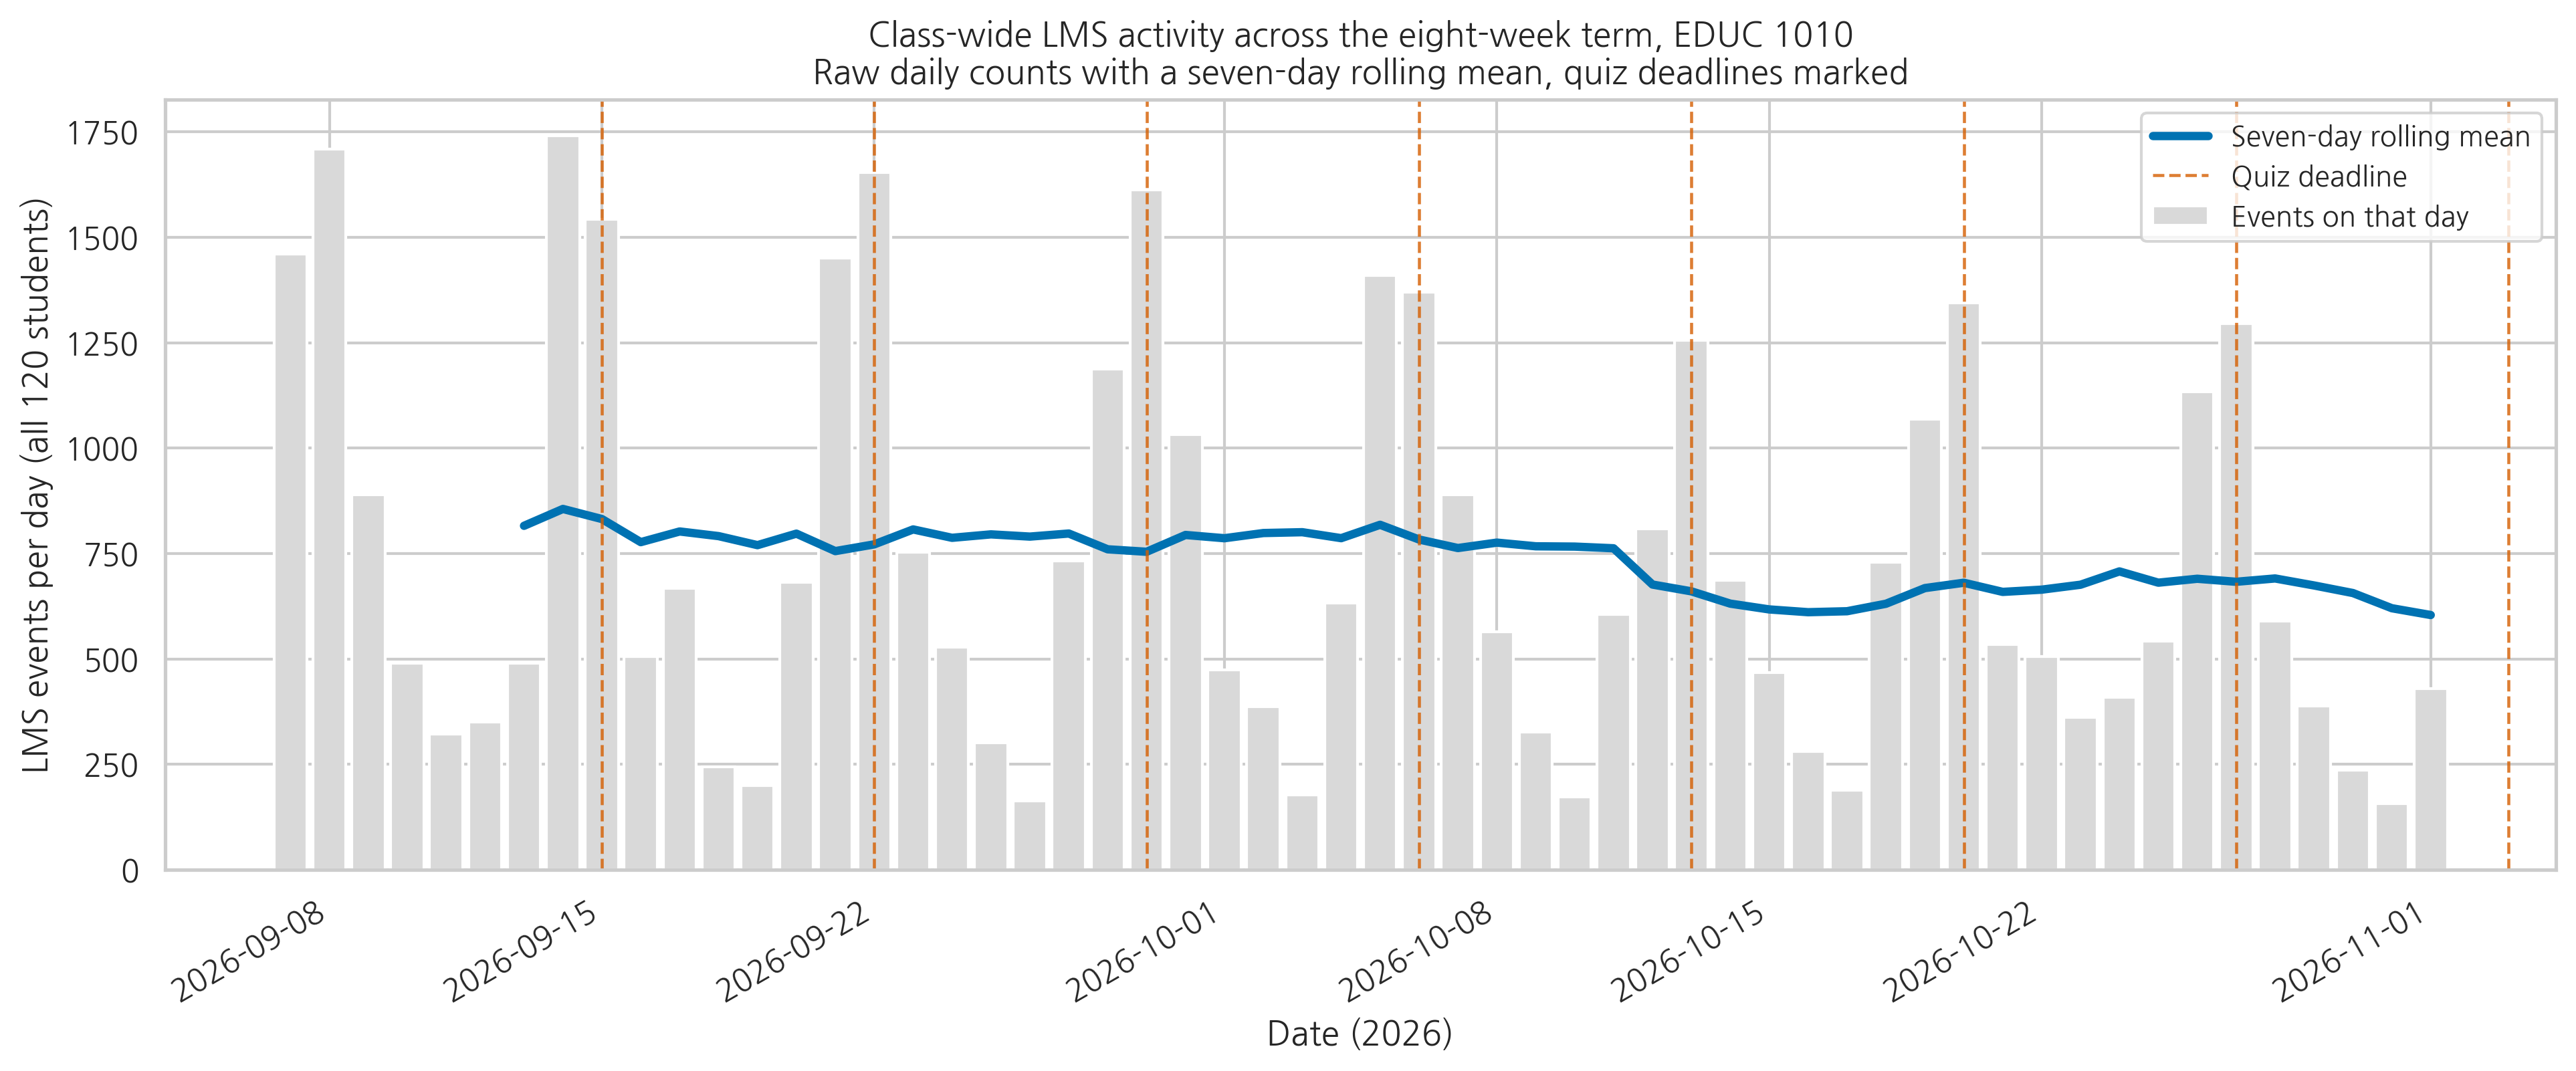

Total LMS events by course week:
week
1    5709
2    5579
3    5581
4    5504
5    5336
6    4415
7    4765
8    4228

Change from weeks 1 and 2 to weeks 7 and 8: -20.3 percent
Clickstream export ends on: 2026-11-01
Last quiz deadline        : 2026-11-03


In [15]:
clicks['date'] = clicks['timestamp'].dt.normalize()
daily = clicks.groupby('date').size().rename('events').to_frame()
daily['rolling7'] = daily['events'].rolling(7, min_periods=7).mean()

deadlines = sorted(quizzes['deadline'].dt.normalize().unique())

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(daily.index, daily['events'], width=0.85, color='#d9d9d9', label='Events on that day')
ax.plot(daily.index, daily['rolling7'], color=BLUE, linewidth=3, label='Seven-day rolling mean')
for i, d in enumerate(deadlines):
    ax.axvline(d, color=VERMILLION, linestyle='--', linewidth=1.1, alpha=0.8,
               label='Quiz deadline' if i == 0 else None)

ax.set_title('Class-wide LMS activity across the eight-week term, EDUC 1010\n'
             'Raw daily counts with a seven-day rolling mean, quiz deadlines marked')
ax.set_xlabel('Date (2026)')
ax.set_ylabel('LMS events per day (all 120 students)')
ax.legend(loc='upper right', fontsize=10)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

weekly_totals = clicks.groupby('week').size()
print('Total LMS events by course week:')
print(weekly_totals.to_string())
print()
print('Change from weeks 1 and 2 to weeks 7 and 8:',
      str(round(100 * (weekly_totals.loc[7:8].sum() / weekly_totals.loc[1:2].sum() - 1), 1)) + ' percent')
print('Clickstream export ends on:', clicks['timestamp'].max().date())
print('Last quiz deadline        :', pd.Timestamp(deadlines[-1]).date())

**💬 Interpretation prompt.** Three things to notice, and the third one is the one people miss.

1. The sawtooth. Activity climbs into each deadline and falls after. That rhythm is invisible in any total.
2. The slope. The rolling mean ends the term meaningfully lower than it started. Name two explanations that
   have nothing to do with students caring less.
3. The right edge. The clickstream export stops on November 1, and the eighth quiz was due on November 3. Any
   claim you make about "engagement before the last quiz" is being made from data that ends before the event.
   Real LMS exports have boundaries like this. Noticing them is the job.

## 2.4 Does timing behavior show up in the weekly rhythm?

We now have two temporal descriptions of the same students: how they submit, and how they click. Putting them
together is a modest test of whether submission timing is a surface symptom of something with a longer arc.

We split the class into students who submitted in the final six hours on at least three of eight quizzes and
everyone else, then plot mean LMS events per student per week for each group. Because week-to-week counts
bounce, we also draw the two-week rolling mean as a heavier line.

Group sizes:
group
Rarely last minute                            92
Often last minute (3 or more of 8 quizzes)    28

Mean LMS events per student per week:
group  Often last minute (3 or more of 8 quizzes)  Rarely last minute
week                                                                 
1                                            40.1                49.8
2                                            44.8                47.0
3                                            49.0                45.8
4                                            39.2                47.9
5                                            32.9                48.0
6                                            32.0                38.2
7                                            31.1                42.3
8                                            26.1                38.0


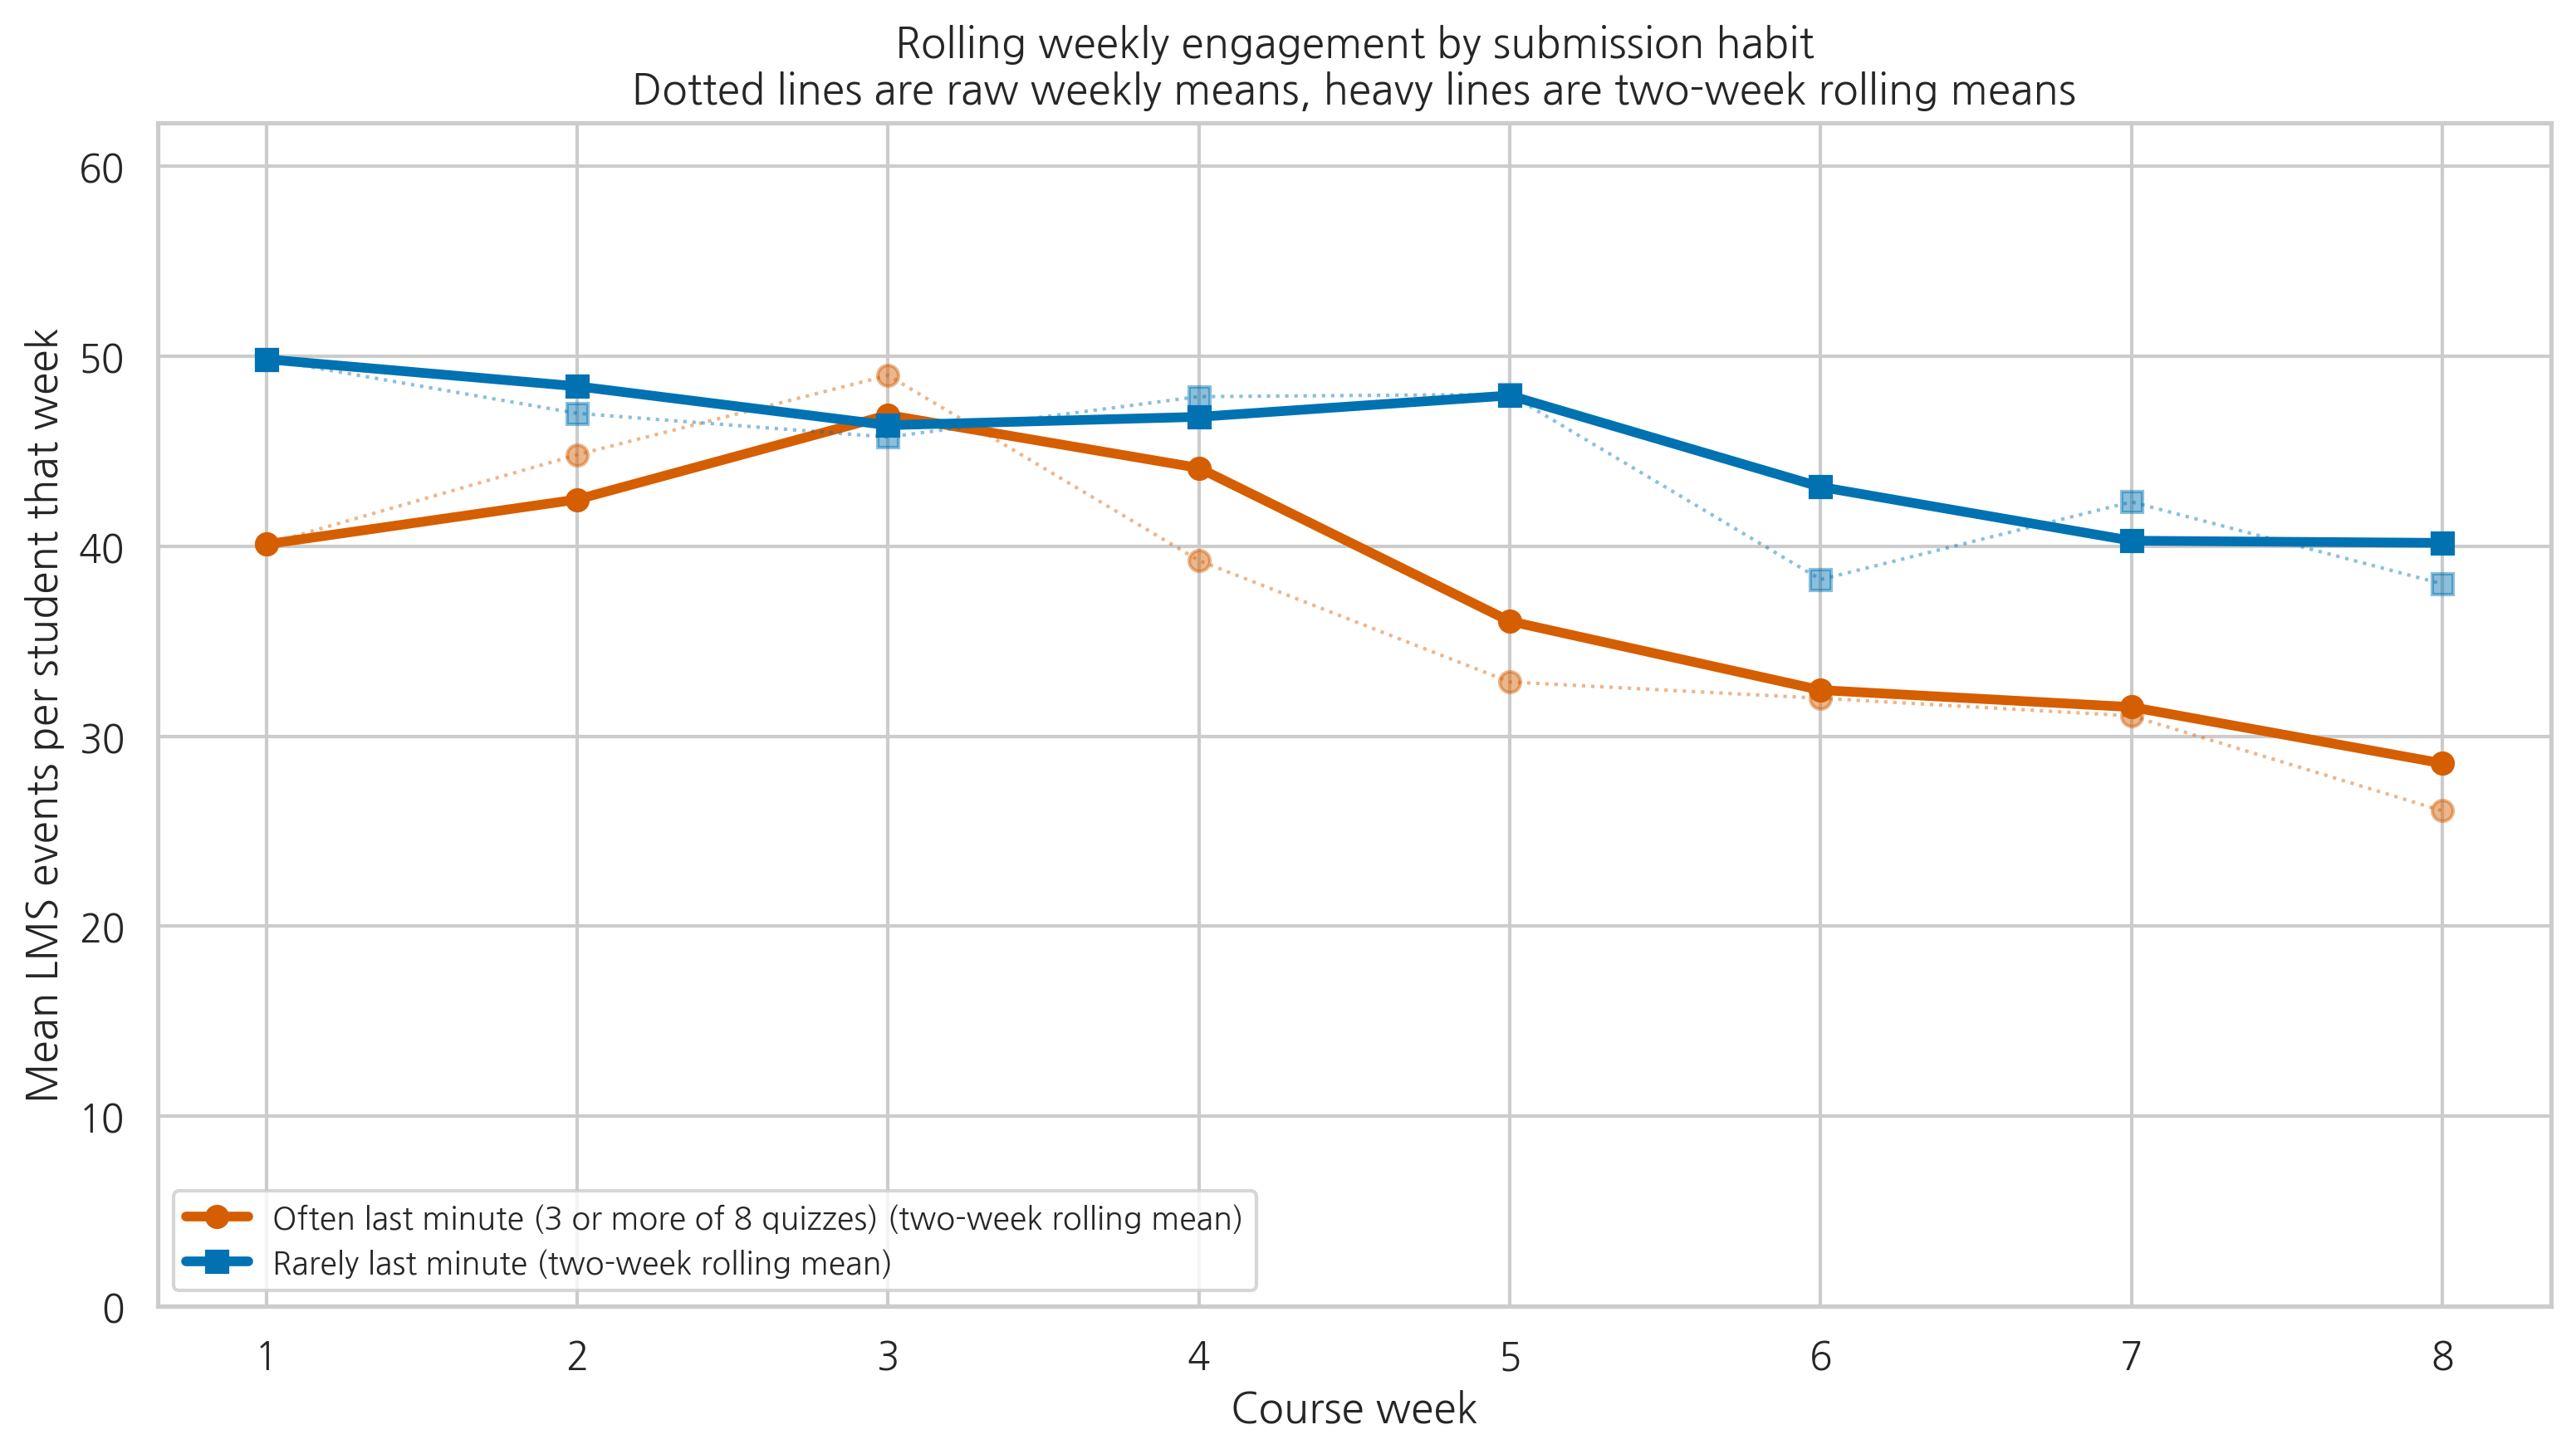

In [16]:
per_student['often_last_minute'] = per_student['share_last_minute'] >= 3 / 8
group_label = dict(zip(per_student['student_id'],
                       np.where(per_student['often_last_minute'],
                                'Often last minute (3 or more of 8 quizzes)',
                                'Rarely last minute')))

weekly = (clicks.groupby(['student_id', 'week']).size()
          .unstack(fill_value=0)
          .reindex(columns=range(1, 9), fill_value=0)
          .reindex(students['student_id']).fillna(0))
weekly['group'] = weekly.index.map(group_label)

group_means = weekly.groupby('group')[list(range(1, 9))].mean().T
group_roll  = group_means.rolling(2, min_periods=1).mean()

print('Group sizes:')
print(weekly['group'].value_counts().to_string())
print()
print('Mean LMS events per student per week:')
print(group_means.round(1).to_string())

fig, ax = plt.subplots(figsize=(10.5, 6))
style = {'Often last minute (3 or more of 8 quizzes)': (VERMILLION, 'o'),
         'Rarely last minute': (BLUE, 's')}
for col in group_means.columns:
    color, marker = style[col]
    ax.plot(group_means.index, group_means[col], color=color, marker=marker,
            linewidth=1, alpha=0.45, linestyle=':')
    ax.plot(group_roll.index, group_roll[col], color=color, marker=marker,
            linewidth=2.8, label=col + ' (two-week rolling mean)')

ax.set_xticks(range(1, 9))
ax.set_ylim(0, max(group_means.max()) * 1.25)
ax.set_title('Rolling weekly engagement by submission habit\n'
             'Dotted lines are raw weekly means, heavy lines are two-week rolling means')
ax.set_xlabel('Course week')
ax.set_ylabel('Mean LMS events per student that week')
ax.legend(loc='lower left', fontsize=9)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** The two groups start close together and separate over the term. Write one
sentence describing the divergence without using any causal verb (no "leads to", "drives", "results in"). Then
answer: at what week would a teacher have had enough evidence to notice this, and what exactly would you have
wanted them to do at that moment? Keep in mind that "flag the student" is an intervention with costs, and the
students in the vermillion group have not done anything wrong.

## 2.5 Two students, one number, two semesters

Back to the week 1 hook. Here are two students whose total LMS activity is nearly identical: 485 events and
480 events. A dashboard reporting activity would have shown them as the same student twice.

They did not have the same semester. One worked in small amounts on forty different days. The other did all of
it in seven concentrated bursts. The panels below plot their daily events on identical axes, with the quiz
deadlines marked.

student_id             name  total_events  active_days  busiest_day  mean_quiz_score  work_hours_per_week
      S012 Bridget Castillo           485           40           26             69.3                   11
      S090      Nikhil Tran           480            7          132             96.4                   16


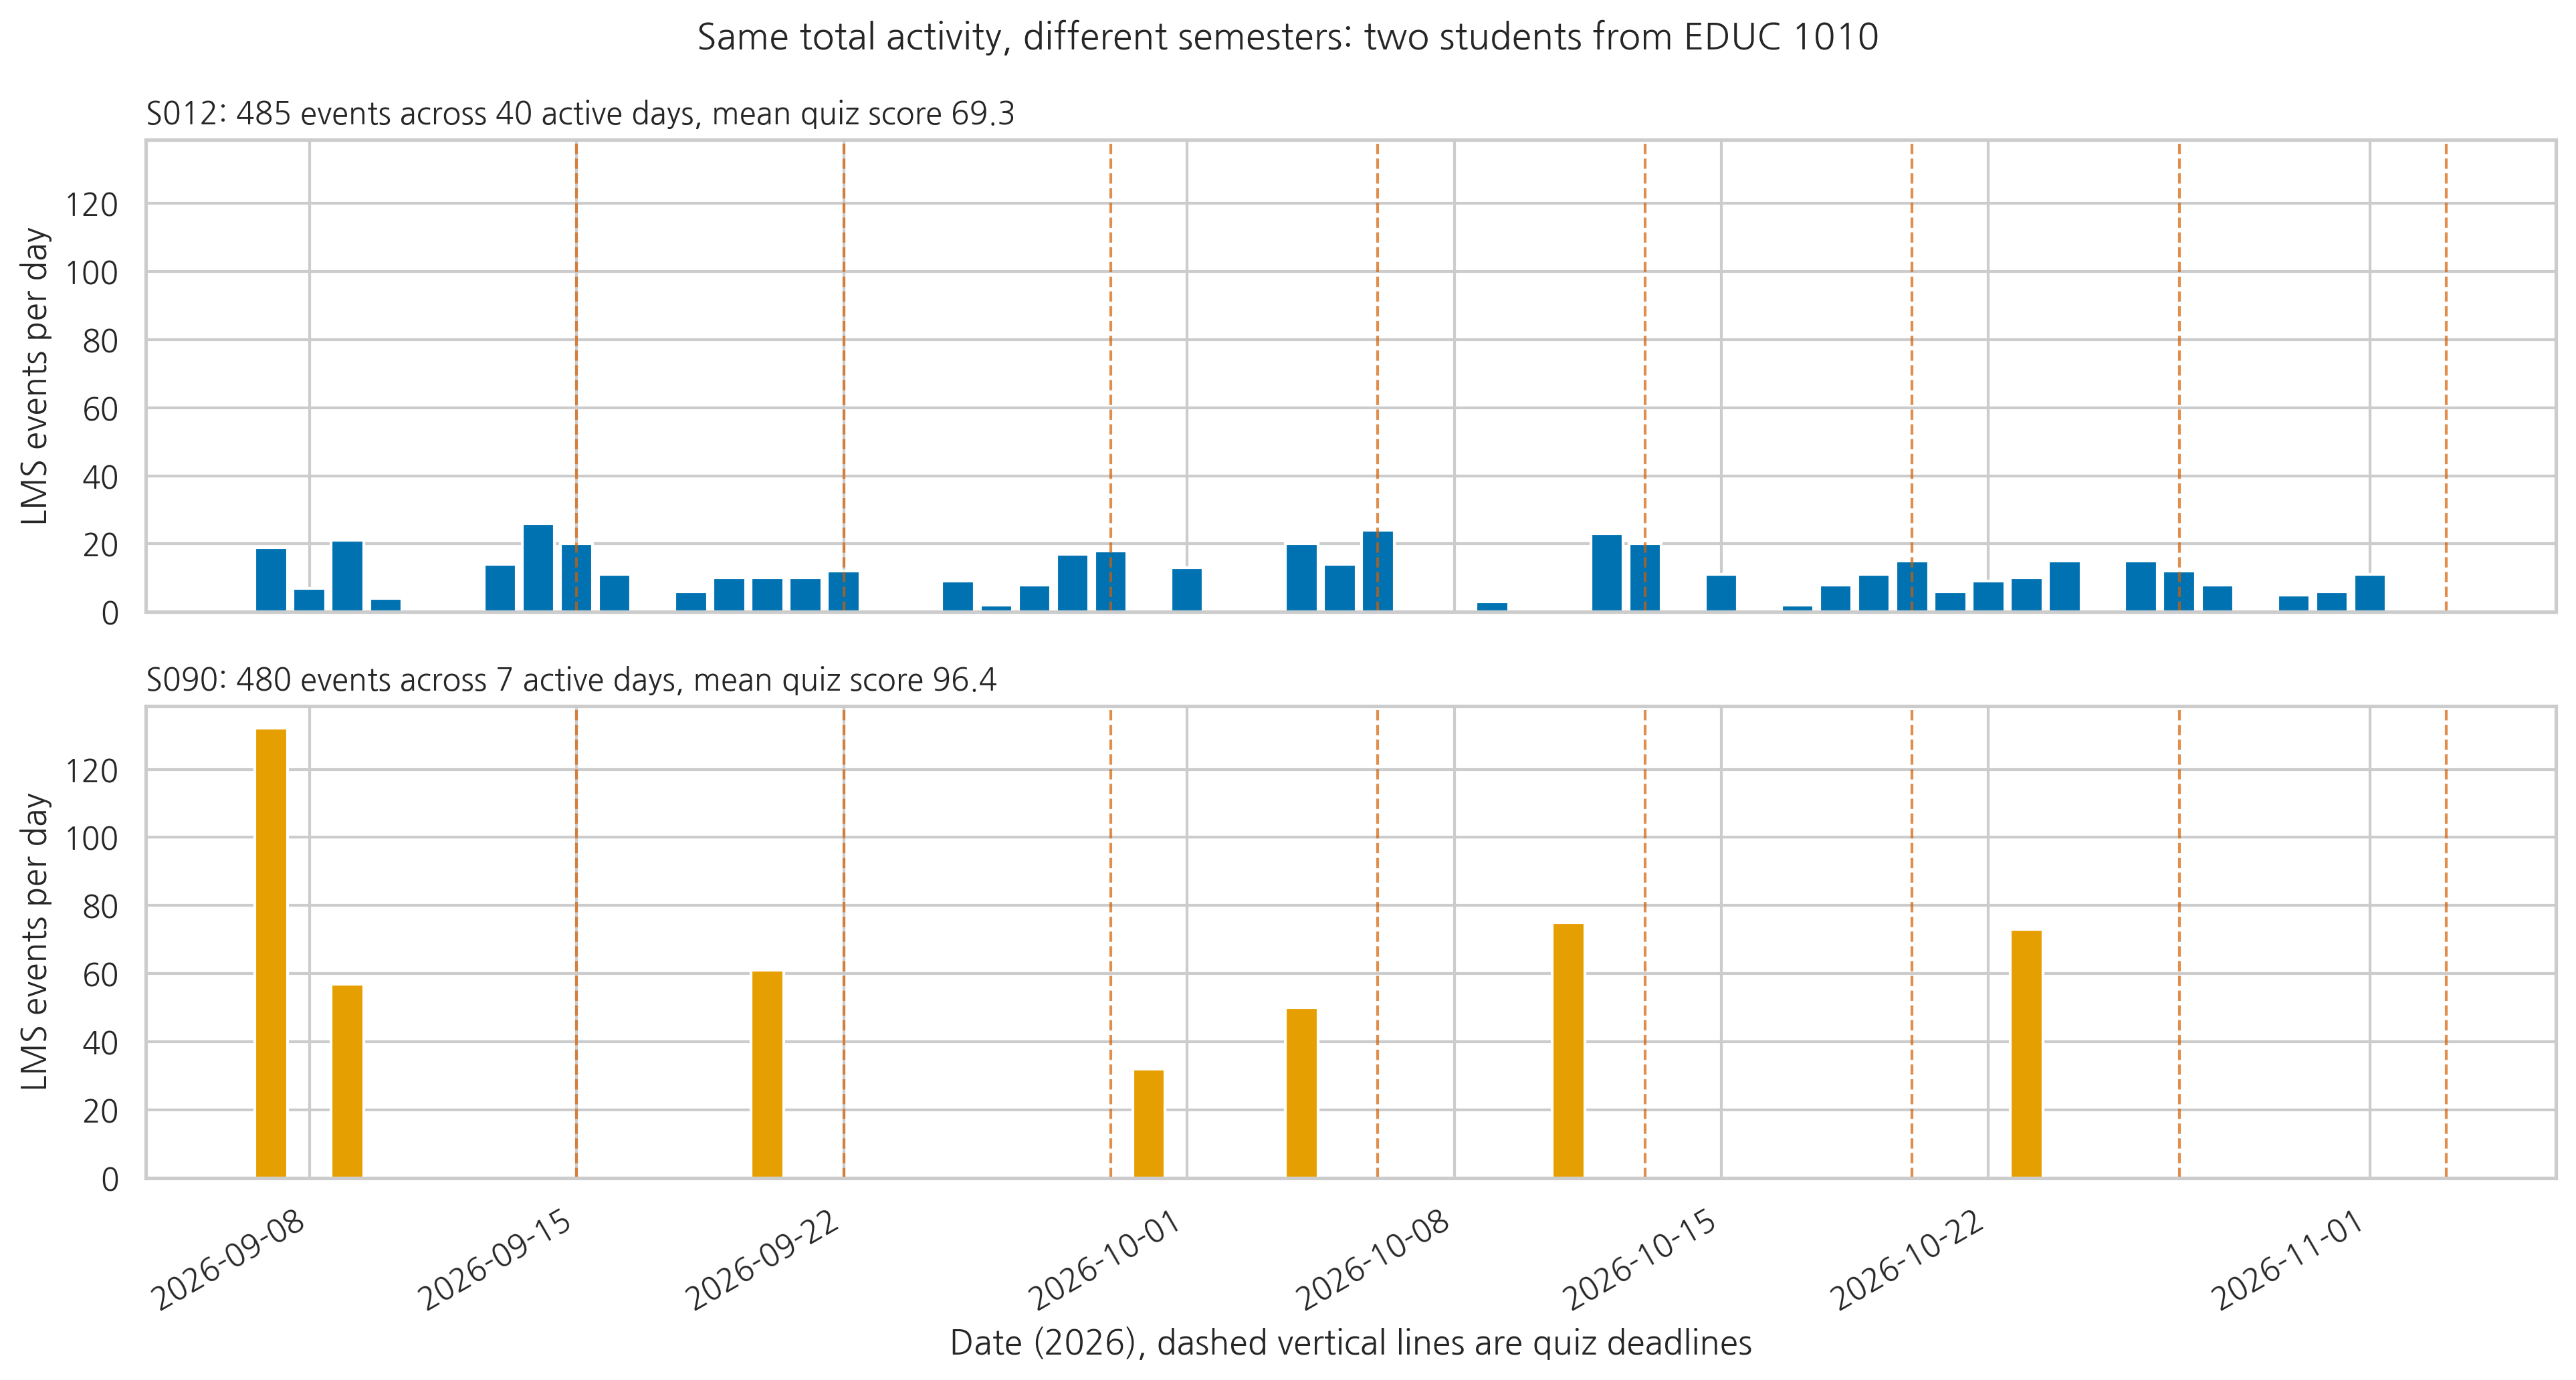

In [17]:
STUDENT_A = 'S012'
STUDENT_B = 'S090'

pair_daily = (clicks[clicks['student_id'].isin([STUDENT_A, STUDENT_B])]
              .groupby(['student_id', 'date']).size().rename('events').reset_index())

all_days = pd.date_range(clicks['date'].min(), clicks['date'].max(), freq='D')
pair_stats = []
for sid in [STUDENT_A, STUDENT_B]:
    s = (pair_daily[pair_daily['student_id'] == sid]
         .set_index('date')['events'].reindex(all_days, fill_value=0))
    row = students.loc[students['student_id'] == sid].iloc[0]
    pair_stats.append({
        'student_id': sid,
        'name': row['first_name'] + ' ' + row['last_name'],
        'total_events': int(s.sum()),
        'active_days': int((s > 0).sum()),
        'busiest_day': int(s.max()),
        'mean_quiz_score': round(float(per_student.loc[per_student['student_id'] == sid,
                                                       'mean_score'].iloc[0]), 1),
        'work_hours_per_week': int(row['work_hours_per_week']),
    })
pair_table = pd.DataFrame(pair_stats)
print(pair_table.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, sharey=True)
for ax, sid, color in zip(axes, [STUDENT_A, STUDENT_B], [BLUE, ORANGE]):
    s = (pair_daily[pair_daily['student_id'] == sid]
         .set_index('date')['events'].reindex(all_days, fill_value=0))
    ax.bar(s.index, s.values, width=0.85, color=color)
    for d in deadlines:
        ax.axvline(d, color=VERMILLION, linestyle='--', linewidth=1.0, alpha=0.7)
    info = pair_table[pair_table['student_id'] == sid].iloc[0]
    ax.set_title(sid + ': ' + str(info['total_events']) + ' events across '
                 + str(info['active_days']) + ' active days, mean quiz score '
                 + str(info['mean_quiz_score']), fontsize=11, loc='left')
    ax.set_ylabel('LMS events per day')

axes[1].set_xlabel('Date (2026), dashed vertical lines are quiz deadlines')
fig.suptitle('Same total activity, different semesters: two students from EDUC 1010', fontsize=13)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** This is the week 1 hook again, with order supplied instead of context.

1. An early-warning system built on "days active in the last two weeks" would have flagged one of these
   students repeatedly. Which one, and what would it have gotten wrong?
2. Look at `work_hours_per_week` in the table. Now reread your answer to question 1. Whose schedule is the
   metric actually measuring? (You met this problem in week 3. It has not gone away, it has just changed
   clothes.)
3. Molenaar and Wise (2022) distinguish between measuring how much of something happened and measuring its
   passage, order, and pacing. Which of the two panels above could you summarize honestly with a single number,
   and what would that number have to be?

## ✏️ Your turn 3: move the last-minute boundary

Six hours is a convention, not a fact about learning. Change `MY_WINDOW_HOURS` below and rerun to see how
stable the finding is. Try `2`, then `12`, then `48`. A result that survives all of those is a different sort
of claim from one that appears only at six.

In [18]:
# TODO: change this to any number of hours you like.
MY_WINDOW_HOURS = 6   # working default

inside  = quizzes.loc[quizzes['lead_hours'].between(0, MY_WINDOW_HOURS), 'score']
outside = quizzes.loc[quizzes['lead_hours'] > MY_WINDOW_HOURS, 'score']

print('Window                :', MY_WINDOW_HOURS, 'hours before the deadline')
print('Submissions inside    :', len(inside),
      '(' + str(round(100 * len(inside) / len(quizzes), 1)) + ' percent of all quizzes)')
print('Mean score inside     :', round(inside.mean(), 2))
print('Mean score outside    :', round(outside.mean(), 2))
print('Difference            :', round(inside.mean() - outside.mean(), 2), 'points')
print("Cohen's d             :", round(cohens_d(inside, outside), 2))

Window                : 6 hours before the deadline
Submissions inside    : 175 (18.2 percent of all quizzes)
Mean score inside     : 68.15
Mean score outside    : 77.61
Difference            : -9.45 points
Cohen's d             : -0.75


## ✏️ Your turn 4: find your own pair

Pick two students whose totals are close and whose rhythms are not. The cell below searches for candidate pairs
automatically, prints the ten closest matches, and then plots whichever pair you name. Change `MY_A` and `MY_B`
to any two student ids from the printed list (or any two ids at all).

Pairs with near-identical totals and very different rhythms: 48
student_a student_b  events_a  events_b  days_a  days_b  score_a  score_b
     S005      S020       269       271      37       5     70.2     77.1
     S005      S087       269       272      37       6     70.2     85.9
     S005      S096       269       268      37      16     70.2     54.2
     S006      S054       157       161      32       4     92.1     58.6
     S008      S062       356       360       7      40     79.4     84.2
     S008      S083       356       359       7      38     79.4     92.5
     S008      S115       356       354       7      38     79.4     97.4
     S009      S019       232       236      43      20     95.4     66.8
     S009      S056       232       237      43       5     95.4     62.5
     S009      S106       232       233      43      12     95.4     67.9


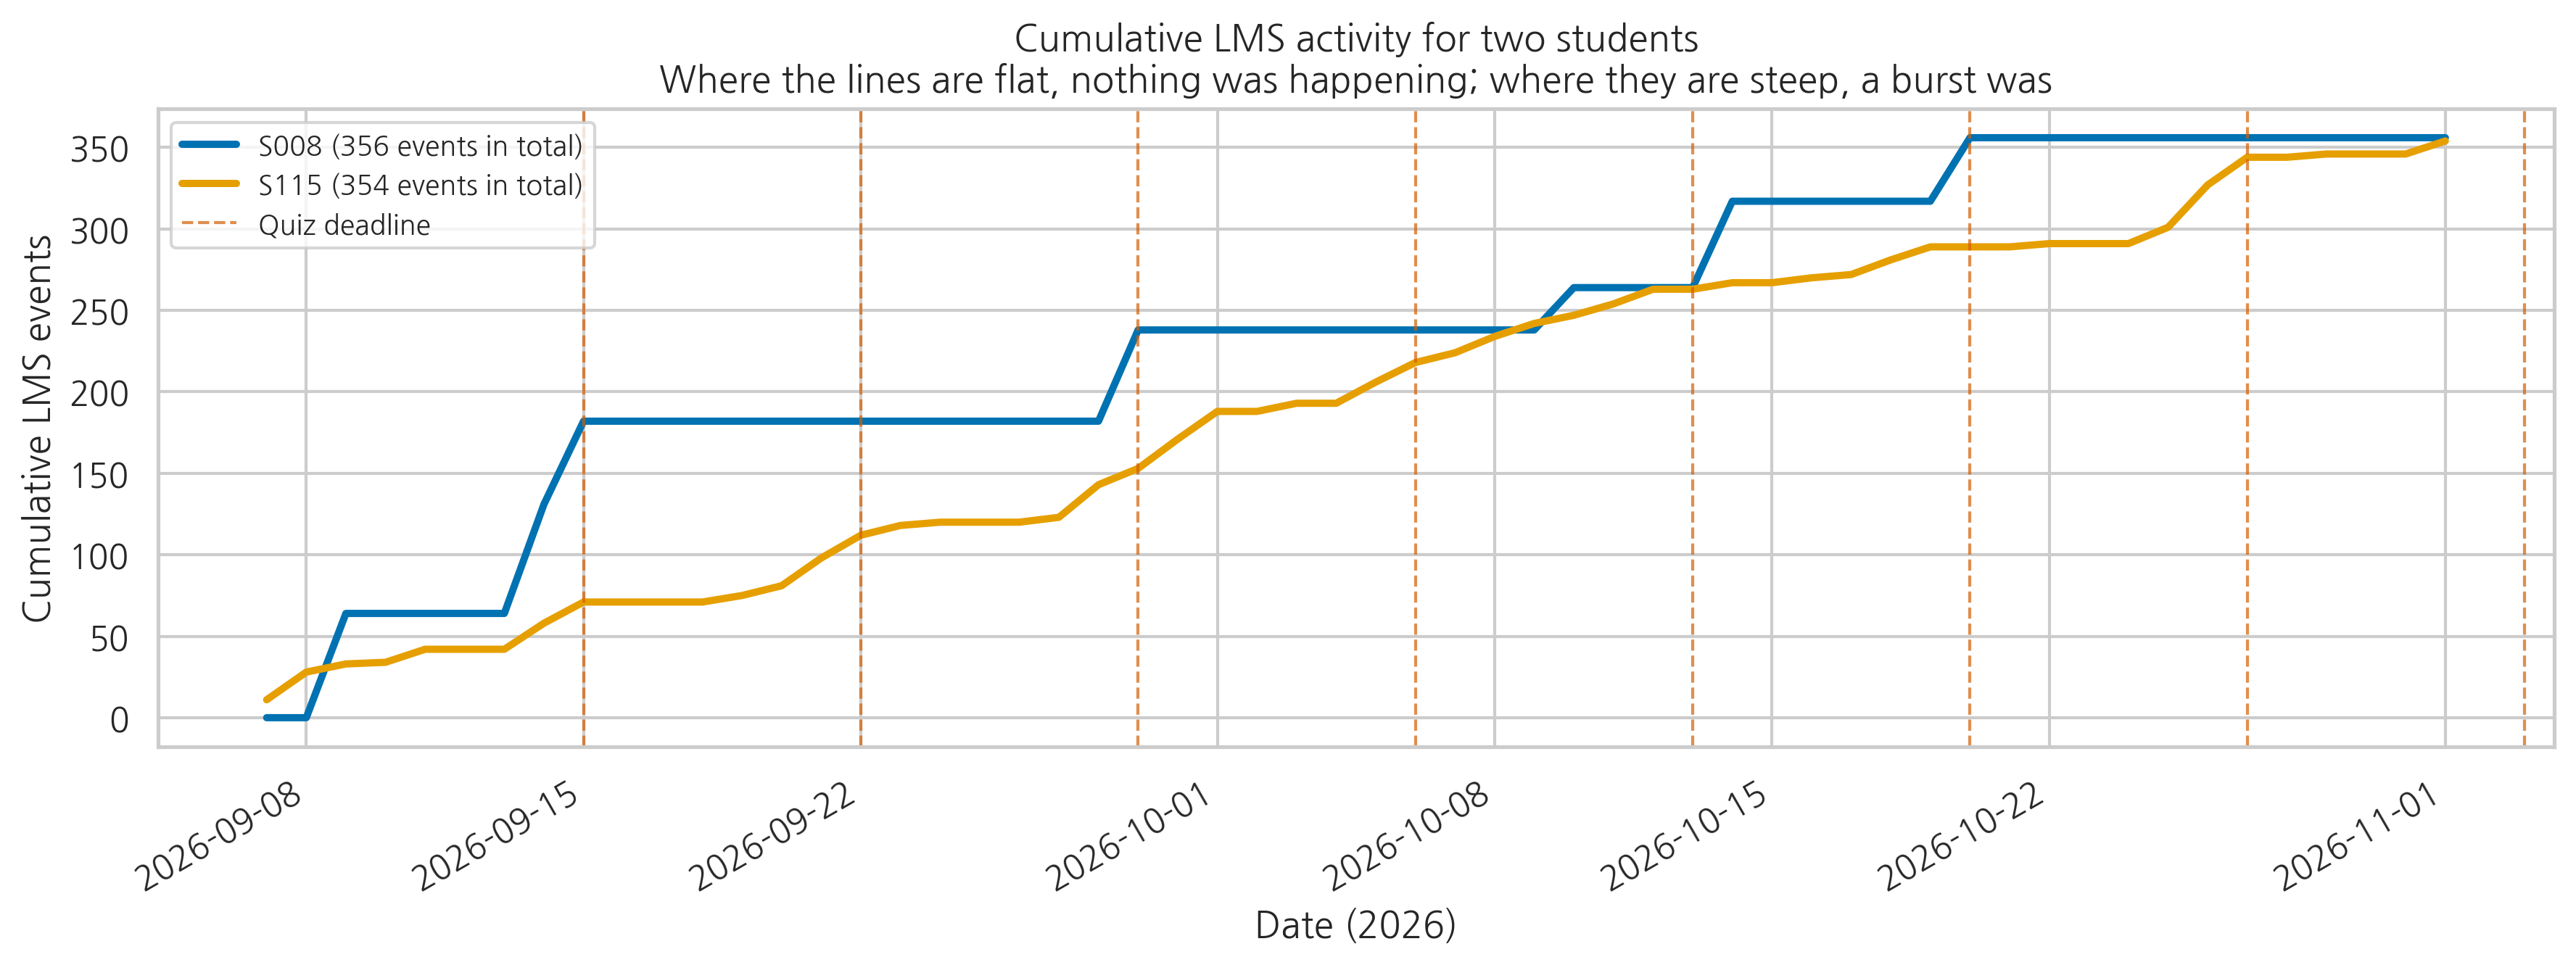

In [19]:
totals      = clicks.groupby('student_id').size().rename('total_events')
active_days = clicks.groupby('student_id')['date'].nunique().rename('active_days')
profile = pd.concat([totals, active_days], axis=1).join(
    per_student.set_index('student_id')['mean_score'])

candidates = []
ids = profile.index.tolist()
for i in range(len(ids)):
    for j in range(i + 1, len(ids)):
        a, b = profile.loc[ids[i]], profile.loc[ids[j]]
        if abs(a['total_events'] - b['total_events']) <= 5 and abs(a['active_days'] - b['active_days']) >= 20:
            candidates.append({'student_a': ids[i], 'student_b': ids[j],
                               'events_a': int(a['total_events']), 'events_b': int(b['total_events']),
                               'days_a': int(a['active_days']), 'days_b': int(b['active_days']),
                               'score_a': round(a['mean_score'], 1), 'score_b': round(b['mean_score'], 1)})
candidates = pd.DataFrame(candidates)
print('Pairs with near-identical totals and very different rhythms:', len(candidates))
print(candidates.head(10).to_string(index=False))

# TODO: change these two ids to any pair you want to look at.
MY_A = 'S008'   # working default
MY_B = 'S115'   # working default

fig, ax = plt.subplots(figsize=(12, 4.6))
for sid, color in zip([MY_A, MY_B], [BLUE, ORANGE]):
    s = (clicks[clicks['student_id'] == sid].groupby('date').size()
         .reindex(all_days, fill_value=0).cumsum())
    ax.plot(s.index, s.values, color=color, linewidth=2.4,
            label=sid + ' (' + str(int(s.iloc[-1])) + ' events in total)')
for i, d in enumerate(deadlines):
    ax.axvline(d, color=VERMILLION, linestyle='--', linewidth=1.0, alpha=0.7,
               label='Quiz deadline' if i == 0 else None)
ax.set_title('Cumulative LMS activity for two students\n'
             'Where the lines are flat, nothing was happening; where they are steep, a burst was')
ax.set_xlabel('Date (2026)')
ax.set_ylabel('Cumulative LMS events')
ax.legend(loc='upper left', fontsize=9)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

---

# 🚀 Stretch: temporal network slices

Everything in Part 1 pooled all eight weeks into one graph, which treats the forum as if it were a single
static object. It is not. People arrive, drift, and reorganize.

This section is optional and runs on its own. It splits the term in half (weeks 1 to 4, weeks 5 to 8), builds a
network for each, and asks whether the connectors are a stable role or a moment. If you have time, this is the
richest place to extend the mini project.

       slice  posts  students  ties  density  avg_degree  communities  modularity  avg_path
Weeks 1 to 4    726        99   474    0.098        9.58            4       0.607      2.74
Weeks 5 to 8    730        98   486    0.102        9.92            3       0.620      2.86

Do the connectors keep bridging in both halves of the term?
student_id  betweenness_weeks_1_4  betweenness_weeks_5_8  rank_weeks_1_4  rank_weeks_5_8
      S020                  0.059                  0.170               7               2
      S101                  0.060                  0.113               6               5
      S031                  0.028                  0.049              21              14
      S043                  0.038                  0.134              13               3


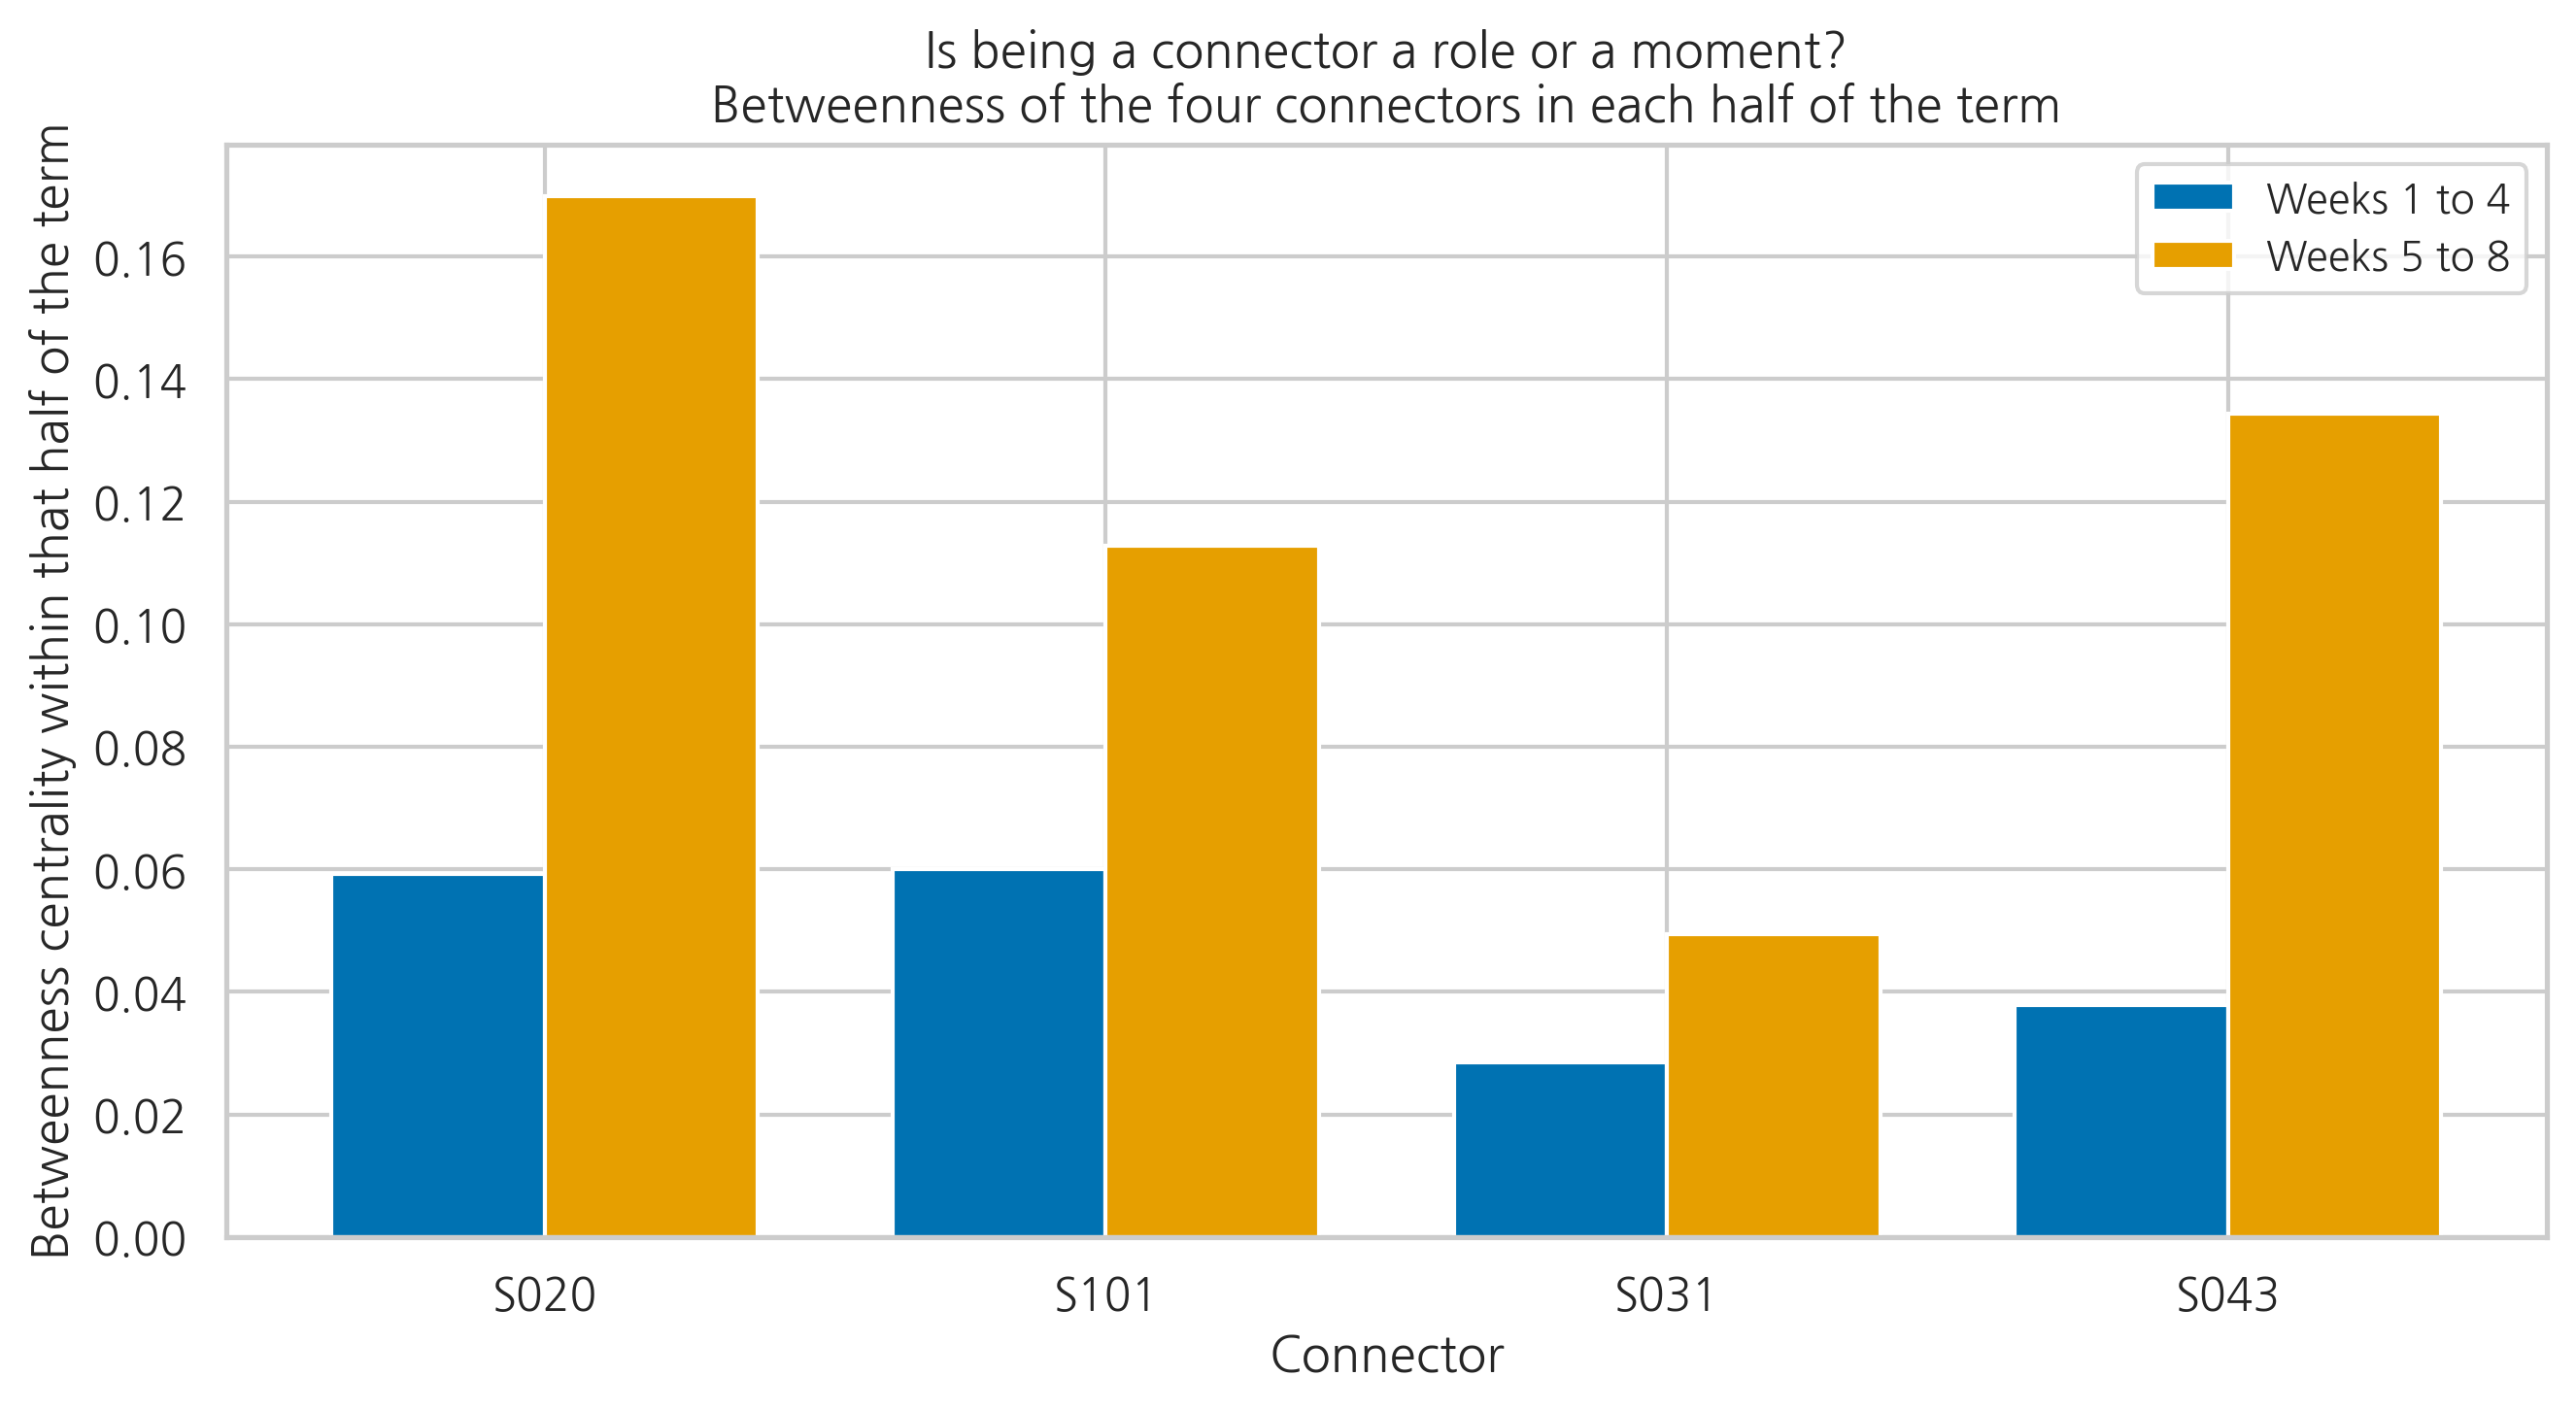

In [20]:
slices = {'Weeks 1 to 4': forum[forum['week'].between(1, 4)],
          'Weeks 5 to 8': forum[forum['week'].between(5, 8)]}

rows, slice_graphs = [], {}
for name, posts in slices.items():
    Gs = build_reply_network(posts)
    slice_graphs[name] = Gs
    comms = nx.community.greedy_modularity_communities(Gs, weight='weight')
    big = Gs.subgraph(max(nx.connected_components(Gs), key=len))
    rows.append({'slice': name, 'posts': len(posts),
                 'students': Gs.number_of_nodes(), 'ties': Gs.number_of_edges(),
                 'density': round(nx.density(Gs), 3),
                 'avg_degree': round(2 * Gs.number_of_edges() / Gs.number_of_nodes(), 2),
                 'communities': len(comms),
                 'modularity': round(nx.community.modularity(Gs, comms, weight='weight'), 3),
                 'avg_path': round(nx.average_shortest_path_length(big), 2)})
print(pd.DataFrame(rows).to_string(index=False))

btw_early = nx.betweenness_centrality(slice_graphs['Weeks 1 to 4'])
btw_late  = nx.betweenness_centrality(slice_graphs['Weeks 5 to 8'])

compare = pd.DataFrame({'student_id': connector_ids})
compare['betweenness_weeks_1_4'] = compare['student_id'].map(btw_early).fillna(0)
compare['betweenness_weeks_5_8'] = compare['student_id'].map(btw_late).fillna(0)
compare['rank_weeks_1_4'] = compare['student_id'].map(
    pd.Series(btw_early).rank(ascending=False).astype(int).to_dict())
compare['rank_weeks_5_8'] = compare['student_id'].map(
    pd.Series(btw_late).rank(ascending=False).astype(int).to_dict())
print()
print('Do the connectors keep bridging in both halves of the term?')
print(compare.round(3).to_string(index=False))

x = np.arange(len(compare))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.19, compare['betweenness_weeks_1_4'], width=0.38, color=BLUE, label='Weeks 1 to 4')
ax.bar(x + 0.19, compare['betweenness_weeks_5_8'], width=0.38, color=ORANGE, label='Weeks 5 to 8')
ax.set_xticks(x)
ax.set_xticklabels(compare['student_id'])
ax.set_title('Is being a connector a role or a moment?\n'
             'Betweenness of the four connectors in each half of the term')
ax.set_xlabel('Connector')
ax.set_ylabel('Betweenness centrality within that half of the term')
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

**💬 Interpretation prompt.** Compare the two halves in the summary table first: the number of communities, the
modularity, and the average path length. Is the forum's structure stable, or did the class reorganize?

Then look at the bar chart. A connector whose betweenness holds up across both halves is playing a role. A
connector who appears in only one half was in the right place at the right time. Which of the four are which,
and how would that distinction change what you would say to an instructor who asked "who is holding this
discussion together"?

If you want to push further: rebuild the slices week by week instead of by halves, and plot each connector's
betweenness as a line over eight weeks. Eight-week networks are thin, so watch the ties count before you trust
any ranking.

---

# ✍️ Your network reading memo

This is a required part of Mini Project 4. Write it in the cell below (double click the cell to edit it), or
write it in a document and upload it alongside the notebook, whichever you prefer.

**Roughly 400 to 500 words.** Address all four:

1. **What the network shows.** Describe the structure of this forum for a reader who has not seen the figures.
   Use numbers, and be specific about which measure you are using at each point.
2. **The connectors.** Who are they, what makes them different from the highest degree students, and what would
   change in this forum without them? Say what you would need to know beyond this dataset before you were
   willing to act on the finding.
3. **The temporal half.** State the submission timing pattern and the strongest alternative explanation for it.
   Then say what a defensible response from an instructor would be, given that alternative.
4. **Limits, ethics, and equity.** Who is invisible in these analyses, and what would it cost them to be made
   visible? Reference at least one of this week's readings by author and year (Poquet and Joksimovic, 2022;
   Molenaar and Wise, 2022; or Yan et al., 2025).

### My network reading memo

*(Double click here and replace this text with your memo.)*

**What the network shows.**

**The connectors.**

**The temporal half.**

**Limits, ethics, and equity.**

---

# 💬 Reflection

Answer these in the cell below, in a few sentences each. They are graded as part of the mini project's
Critical Reflection criterion, and they are also the questions the guest speaker is most likely to ask you.

1. **Poquet and Joksimovic (2022)** describe learning analytics as a "cacophony of networks" because the same
   people yield different graphs depending on what the analyst counts as a tie. You built one graph from one
   choice. Name a second tie definition available in this data universe (forum, chat, studio, tutor), and say
   whose importance would rise or fall under it.

2. **Molenaar and Wise (2022)** argue that analyses have to be grounded in an explicit concept of time: time as
   a container to be filled, time as passage, time as order, time as rhythm. Which concept of time was the
   rolling engagement chart using? Which was the twin student comparison in section 2.5 using? Were they the
   same concept?

3. **Yan et al. (2025)** dissect temporal dynamics in collaborative learning by treating sequence, not
   frequency, as the unit of analysis. Take one finding from this notebook and describe how you would redo it
   as a question about sequence instead of a question about totals. What data would you need that you do not
   have?

4. **The connector question, asked seriously.** If you told an instructor that four specific students hold this
   forum together, what could go well and what could go badly? Consider what happens to a student who is told
   they are a bridge, and what happens to one who is told they are not.

5. **Guest speaker connection.** Yukyeong Song (University of Tennessee, Knoxville) works on fairness in
   behavioral pattern detection. Pick one threshold you set in this notebook (the bridge share cutoff, the
   six-hour window, the three-of-eight grouping) and say who could be systematically misclassified by it.

### My reflection

*(Double click here and replace this text with your answers.)*

**1.**

**2.**

**3.**

**4.**

**5.**

---

# ✅ Submission checklist

**Mini Project 4 is due this week via Canvas.** Check the Canvas assignment page for the exact time.

Before you submit:

- [ ] The notebook runs top to bottom without errors. Use `Runtime` > `Restart session and run all` and watch
      it go green all the way down.
- [ ] All four **✏️ Your turn** cells have been edited at least once, and the notebook still runs afterward.
- [ ] Every **💬 Interpretation prompt** has a written answer in a markdown cell beneath it.
- [ ] Your **network reading memo** (400 to 500 words) is complete, either in the memo cell or as a separate
      document.
- [ ] The **💬 Reflection** section is answered, referencing this week's readings by author and year.
- [ ] Download the notebook: `File` > `Download` > `Download .ipynb`. Upload it to the Mini Project 4
      assignment on Canvas.

**AI interaction log and reflection (required, separate Canvas submission).**

The course AI policy permits AI use in this activity and requires that you document it. Upload to the **AI
Interactions** submission on Canvas:

- [ ] A log of your AI interactions for this mini project: which tool, what you asked, what it gave you, and
      what you changed. Copy and paste transcripts or link to shared conversations.
- [ ] A short reflection (a paragraph is enough): where the AI helped, where it was wrong or misleading, and
      how you verified anything you kept. If you used no AI at all, say so in one line. That is a complete and
      acceptable log.

Undisclosed AI use is an Honor Code violation. Disclosed AI use costs you nothing.

**Grading.** See the rubric in this folder's `README.md`: five criteria at 20 points each (End-to-End Analytics
Workflow, Data Preparation and Technical Care, Analysis and Visualization Choices, Interpretation and
Educational Meaning, Critical Reflection on Limits, Ethics, and Equity).

---

# 📎 Appendix: solutions to the "Your turn" cells

Read these after you have tried the exercises. They are here so you can check your reasoning, not so you can
skip the attempt. Each block is a working answer, not the only one.

### Your turn 1: moving the connector thresholds

```python
MY_MIN_DEGREE    = 5
MY_BRIDGE_CUTOFF = 0.25
```

Dropping the cutoff from 0.40 to 0.25 typically adds no one for a while, then starts admitting students whose
bridge share is in the 0.15 to 0.20 range. That gap in the bar chart is the real finding: the four connectors
are separated from everyone else by a wide margin, so the exact cutoff barely matters between roughly 0.25 and
0.40. Setting `MY_MIN_DEGREE = 2` is the instructive failure. Students with two or three ties can post a bridge
share of 0.5 or 1.0 by accident, and the list fills with people whose "bridging" rests on a single reply.

The lesson to carry into your memo: report the sensitivity, not just the threshold. "Four students clear a
bridge share of 0.40, and the same four are the only ones above 0.25" is a much stronger sentence than "four
students clear 0.40".

### Your turn 2: one week at a time

```python
WEEK_TO_INSPECT = 7
```

Any single week has roughly one eighth of the ties, so density falls, the graph often breaks into more than one
component, and the top of the betweenness ranking changes from week to week. Some students appear in the weekly
top five once and never again.

That instability is a real result about the measure, not a flaw in your code. Betweenness computed on a sparse
graph is high variance. If you want a weekly claim you need either more data per week or a measure that
degrades gracefully, such as simple degree.

### Your turn 3: moving the last-minute boundary

```python
MY_WINDOW_HOURS = 2    # then 12, then 48
```

At 2 hours the group is small (a hundred or so submissions) and the gap is large. At 12 and 24 hours the group
grows and the gap narrows but stays in the same direction. At 48 hours you are no longer measuring
"last minute", you are measuring "not more than two days early", and the comparison group has become the small
one.

The pattern is monotone and does not depend on the six-hour choice, which is worth stating explicitly in your
memo. Directional stability across thresholds is evidence. It is still not causal evidence.

### Your turn 4: find your own pair

```python
MY_A = 'S009'
MY_B = 'S112'
```

The search finds dozens of pairs, because near-identical totals with very different rhythms are common rather
than exotic. That is the substantive point: in this class, the total is nearly uninformative about the shape.

The cumulative plot is often clearer than the daily bars for this comparison. A steady student's line is close
to straight. A burst student's line is a staircase: long flat stretches, then near-vertical climbs in the day
or two before a deadline. Both lines end at the same height.

Be careful about which pairs you choose to present. It is easy to pick a pair that flatters a story about
diligence. Look at `work_hours_per_week`, `first_gen`, and `prior_gpa` for whoever you select before you write
a sentence about what their rhythm means.

---

*EDIS 8100: Teaching and Learning Analytics · Fall 2026 · University of Virginia*
*Course and data universe designed by Dr. Hakeoung Hannah Lee. All data in this notebook are synthetic.*